In [1]:
# importing librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, log
from pandas.plotting import scatter_matrix
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.cluster  import  KMeans
from  sklearn.metrics  import confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC
from sklearn.svm import SVR
from matplotlib.pyplot import table
from sklearn.metrics import mean_absolute_error





# Data Exploration

## 1. Data and variable's types

We therefore begin exploring our data by understanding the variables and their types.

In [2]:
# Lecture des données
# Charger les données
hsd_raw=pd.read_csv("healthcare_synthetic_data.csv",sep=",",header=0)
# Vérification de la forme des données
hsd_raw.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


Our first step is to check the types of every variables to be sure it is well adapted with the data the variable represent.

In [3]:
hsd_raw.dtypes

Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

We can see that qualitative variables are treated as character strings or integers. We create two sub-lists of qualitative and quantitative variables so that we can process them separately. As we discuss in class, we take Sleep_Hours and Stress_Level as quantitative variables because our models will be lighter to run (because a quantitative variable needs only one estimator, while a qualitative variable with k modalities needs k-1 estimators). The proportion of quantitative variables will be greater than the qualitative ones and we believe that it will be worth for the accuracy of models also.

In [4]:
qualitative_var = ["Gender", "Smoking_Status", "Alcohol_Consumption", "Physical_Activity_Level", 
                   "Family_History","Heart_Disease_Risk"]

quantitative_var = ["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP", "Cholesterol_Total",
                    "Cholesterol_LDL","Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours"]

hsd = hsd_raw.copy()

for i in qualitative_var:
    hsd[i]=pd.Categorical(hsd[i])



In [5]:
hsd.dtypes


Patient_ID                      str
Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level                  int64
Sleep_Hours                   int64
Heart_Disease_Risk         category
dtype: object

In [6]:
print(f"The proportion of quantitative variables is {round(len(quantitative_var)/hsd.shape[1] *100, 2)}%.")
print(f"The proportion of qualitative variables is {round(len(qualitative_var)/hsd.shape[1] *100, 2)}%.")

The proportion of quantitative variables is 63.16%.
The proportion of qualitative variables is 31.58%.


## 2. Analyse unidimensionnelle

### 1. Qualitative variables


--- Résumé pour la variable : Gender ---
Gender
0    7622
1    7378
Name: count, dtype: int64

Pourcentages :
Gender
0    50.813333
1    49.186667
Name: proportion, dtype: float64

--- Résumé pour la variable : Smoking_Status ---
Smoking_Status
0    10495
1     4505
Name: count, dtype: int64

Pourcentages :
Smoking_Status
0    69.966667
1    30.033333
Name: proportion, dtype: float64

--- Résumé pour la variable : Alcohol_Consumption ---
Alcohol_Consumption
0    7502
1    5939
2    1559
Name: count, dtype: int64

Pourcentages :
Alcohol_Consumption
0    50.013333
1    39.593333
2    10.393333
Name: proportion, dtype: float64

--- Résumé pour la variable : Physical_Activity_Level ---
Physical_Activity_Level
0    3020
1    6009
2    4453
3    1518
Name: count, dtype: int64

Pourcentages :
Physical_Activity_Level
0    20.133333
1    40.060000
2    29.686667
3    10.120000
Name: proportion, dtype: float64

--- Résumé pour la variable : Family_History ---
Family_History
0    12757
1     224

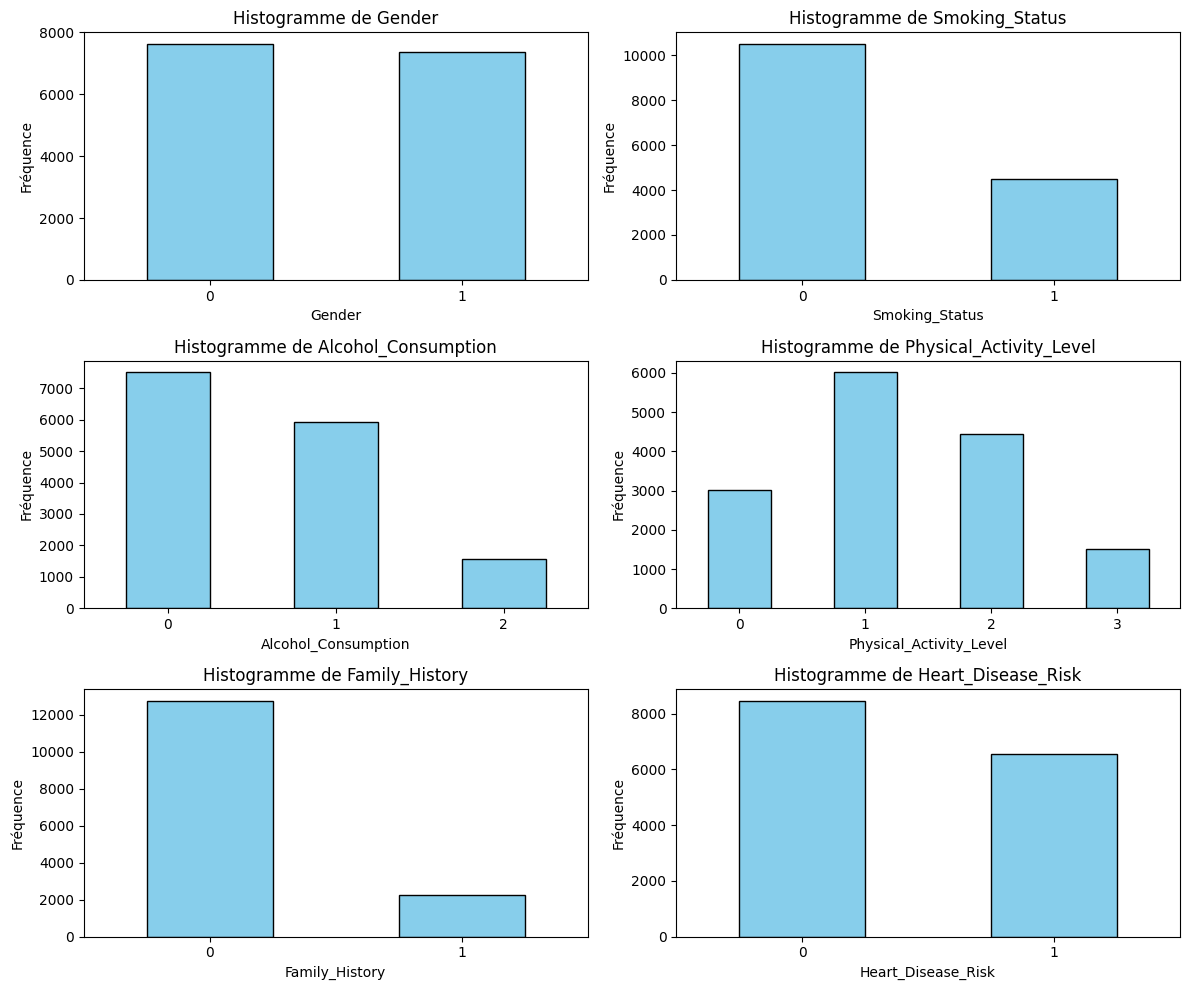

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for idx, var in enumerate(qualitative_var):
    print(f"\n--- Résumé pour la variable : {var} ---")
    print(hsd[var].value_counts(dropna=False).sort_index())
    print("\nPourcentages :")
    print(hsd[var].value_counts(dropna=False, normalize=True).sort_index() * 100)
    
    # Plot on the corresponding subplot
    hsd[var].value_counts().sort_index().plot(
        kind='bar', 
        ax=axes[idx], 
        title=f"Histogramme de {var}",
        color='skyblue',
        edgecolor='black'
    )
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("Fréquence")
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Qualitative variables seem well represented with a good repartition between individuals. We know can take attention at the quantitatives variables.

### 2. Quantitative variables

In [8]:
hsd.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


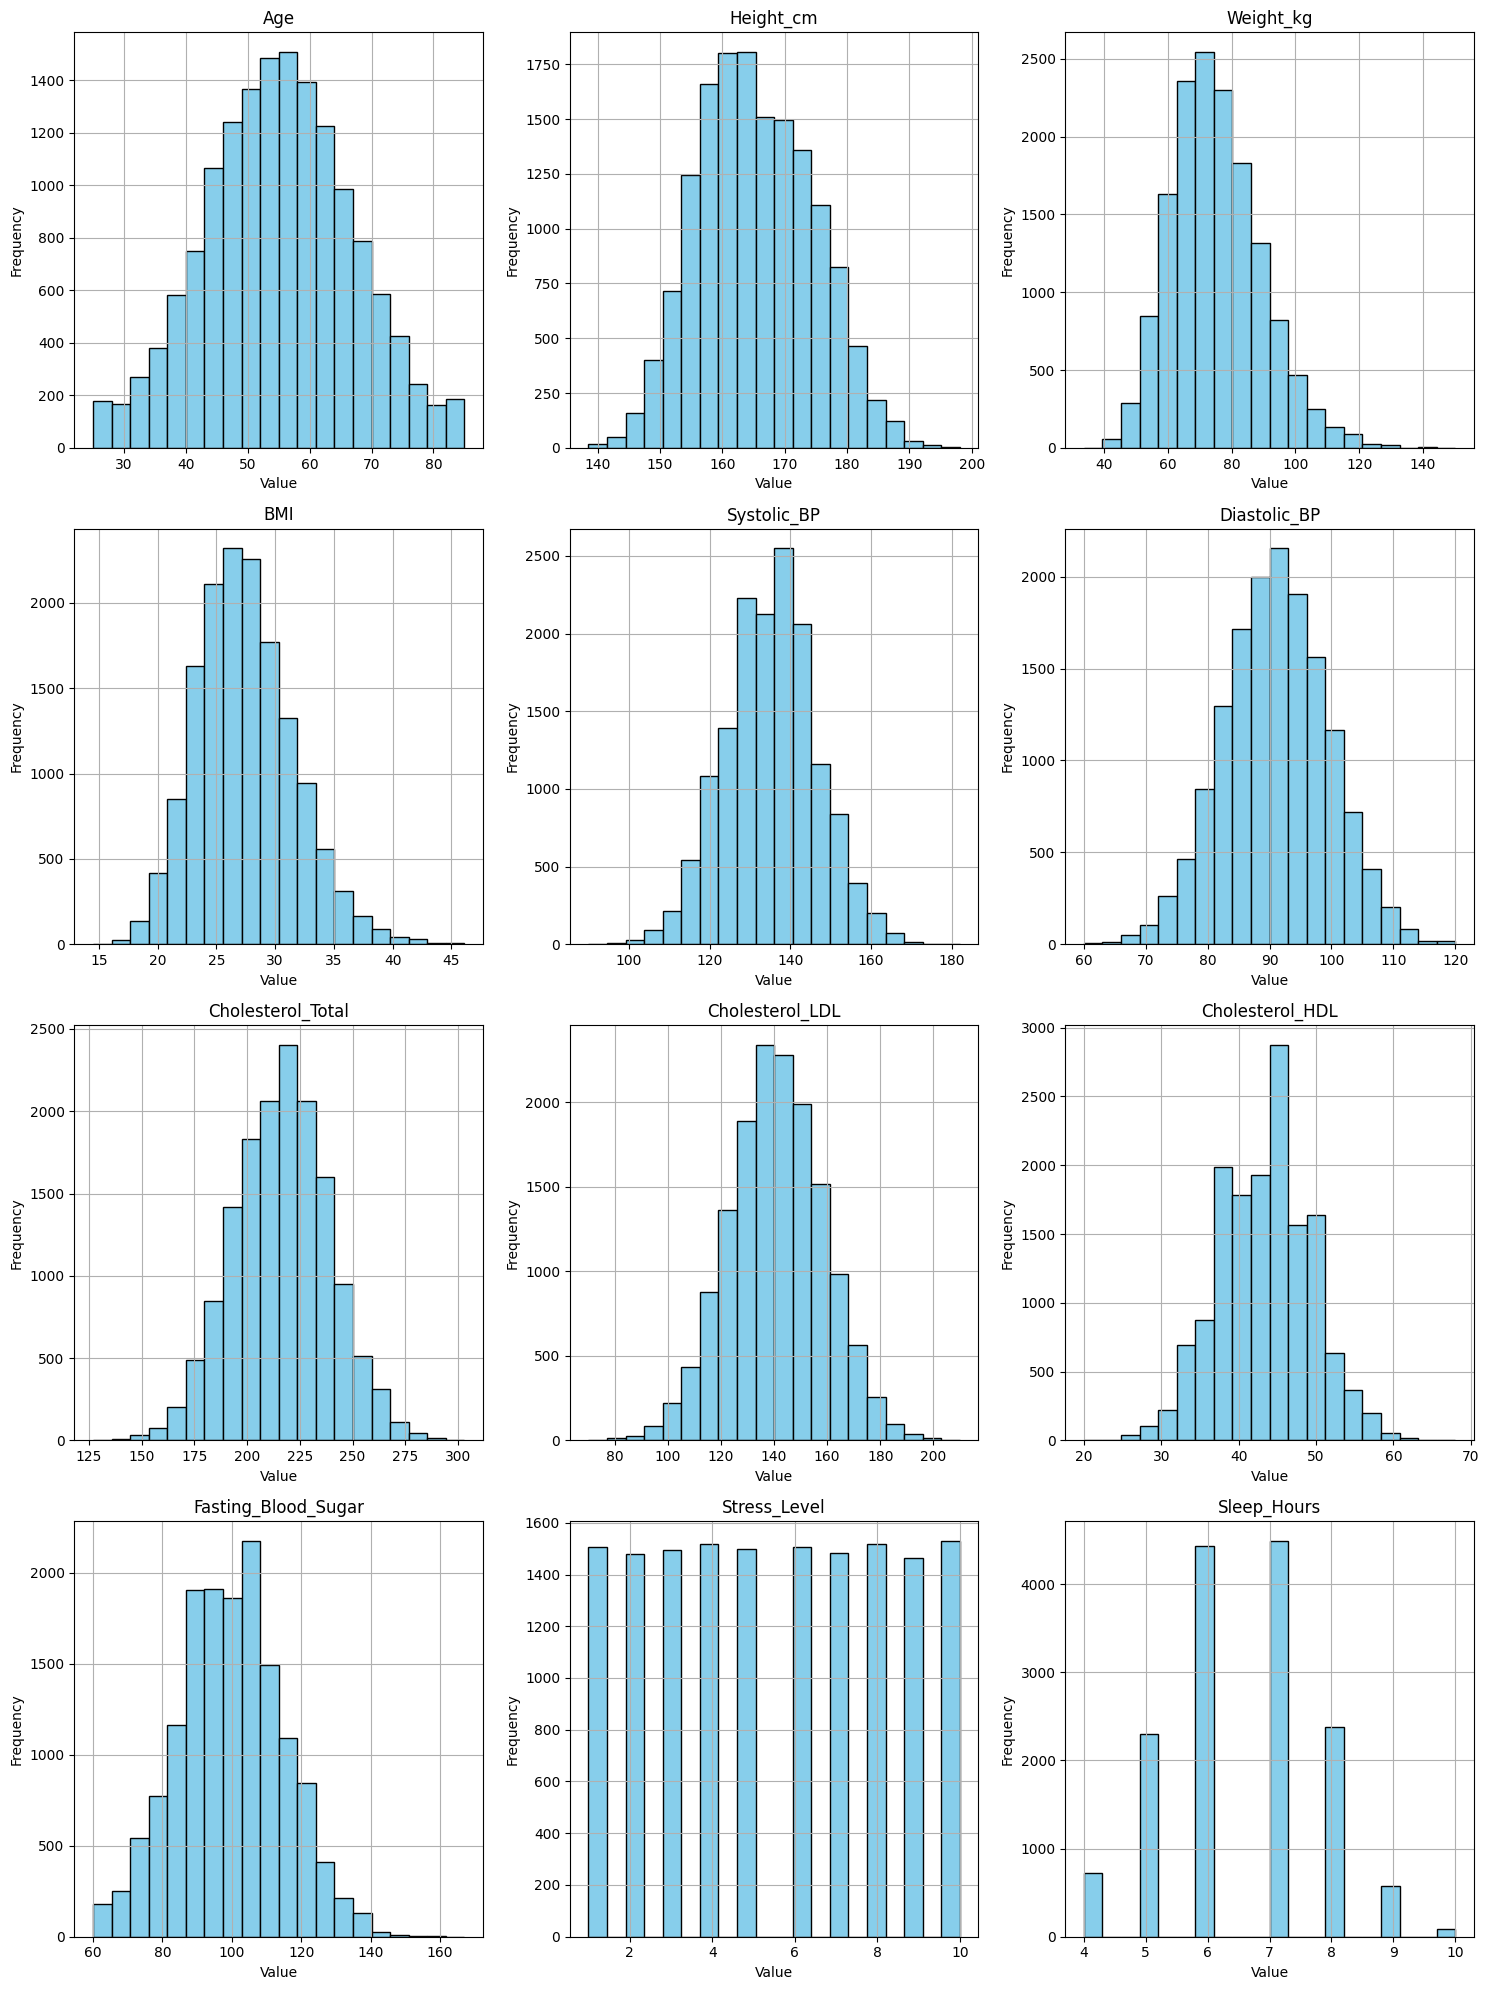

In [9]:
# histograms for quantitative variables
num_vars = len(quantitative_var)
num_cols = 3  # Number of columns in the subplot grid
num_rows = (num_vars + num_cols - 1) // num_cols  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, var in enumerate(quantitative_var):
    ax = axes[i]
    hsd[var].hist(ax=ax, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Our aim now is to have all variables Gaussian shaped. We can observe 5 variables who are not distributed as gaussian : BMI, Weight_kg, Height_cm, Fasting_Blood_Sugar and Cholesterol_HDL. Let's try 2 different transformations (sqrt and log) to see if it can improve their shape.



In [10]:
hsd["LBMI"]=hsd["BMI"].map(lambda x: log(x))
hsd["SBMI"]=hsd["BMI"].map(lambda x: sqrt(x))

hsd["LFBS"]=hsd["Fasting_Blood_Sugar"].map(lambda x: log(x))
hsd["SFBS"]=hsd["Fasting_Blood_Sugar"].map(lambda x: sqrt(x))

hsd["L_Weight_kg"]=hsd["Weight_kg"].map(lambda x: log(x))
hsd["S_Weight_kg"]=hsd["Weight_kg"].map(lambda x: sqrt(x))

hsd["L_Cholesterol_HDL"]=hsd["Cholesterol_HDL"].map(lambda x: log(x))
hsd["S_Cholesterol_HDL"]=hsd["Cholesterol_HDL"].map(lambda x: sqrt(x))

hsd["L_Height_cm"]=hsd["Height_cm"].map(lambda x: log(x))
hsd["S_Height_cm"]=hsd["Height_cm"].map(lambda x: sqrt(x))


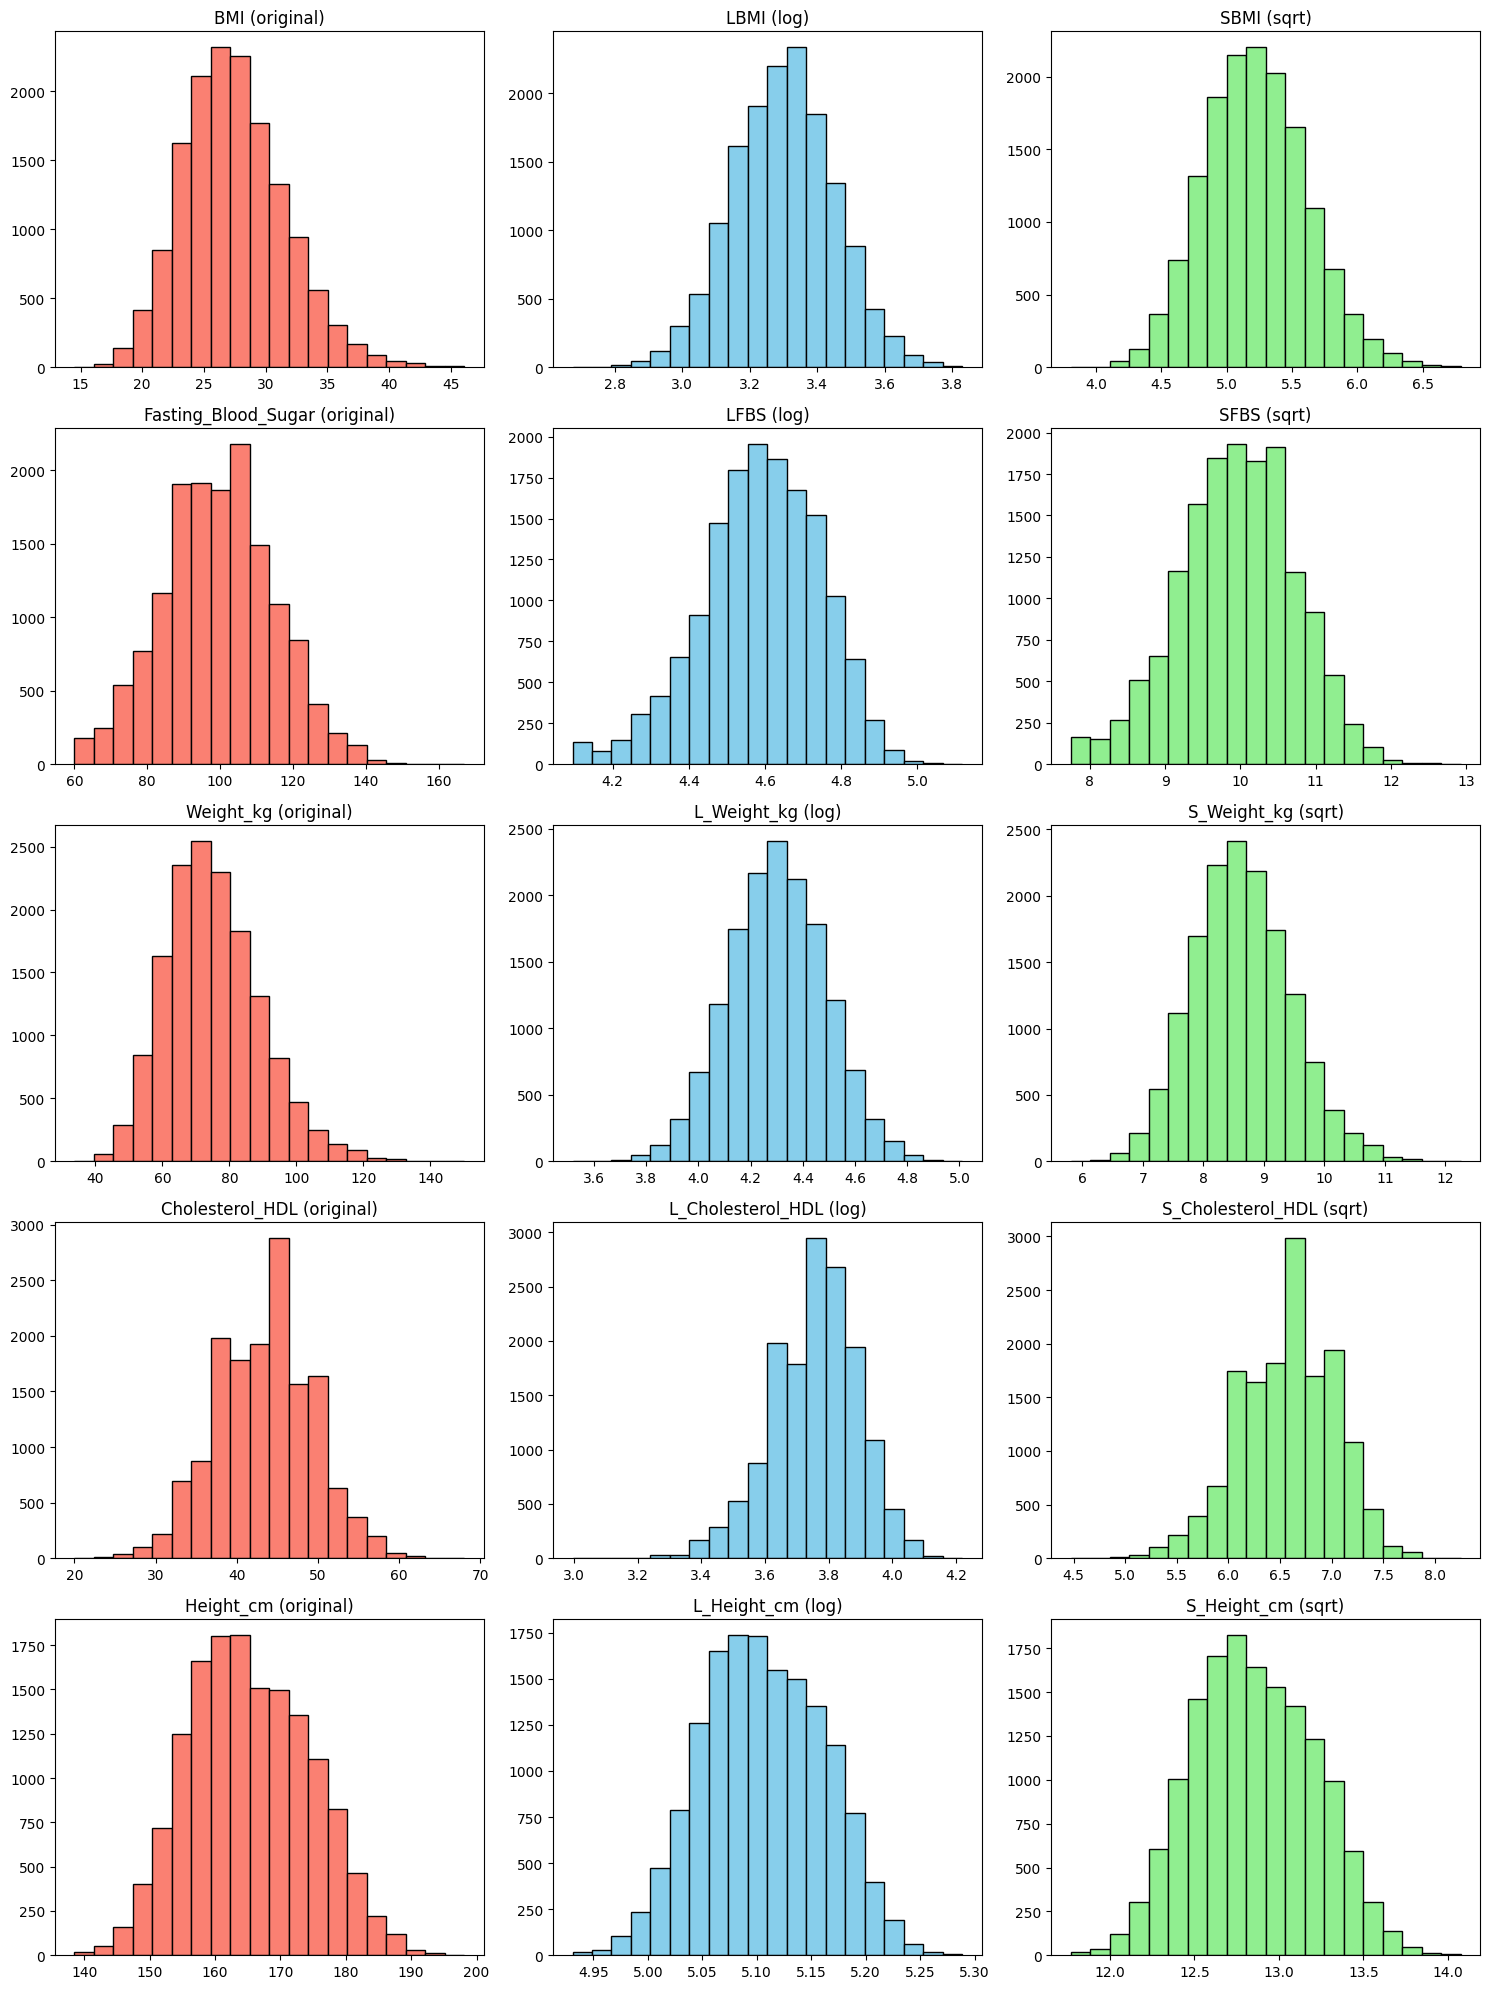

In [11]:
#comparison of original, log and sqrt histograms for selected variables
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))    
axes[0, 0].hist(hsd["BMI"], bins=20, color='salmon', edgecolor='black')
axes[0, 0].set_title("BMI (original)")
axes[0, 1].hist(hsd["LBMI"], bins=20, color='skyblue', edgecolor='black')
axes[0, 1].set_title("LBMI (log)")
axes[0, 2].hist(hsd["SBMI"], bins=20, color='lightgreen', edgecolor='black')
axes[0, 2].set_title("SBMI (sqrt)")

axes[1, 0].hist(hsd["Fasting_Blood_Sugar"], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title("Fasting_Blood_Sugar (original)")
axes[1, 1].hist(hsd["LFBS"], bins=20, color='skyblue', edgecolor='black')
axes[1, 1].set_title("LFBS (log)")
axes[1, 2].hist(hsd["SFBS"], bins=20, color='lightgreen', edgecolor='black')
axes[1, 2].set_title("SFBS (sqrt)")

axes[2, 0].hist(hsd["Weight_kg"], bins=20, color='salmon', edgecolor='black')
axes[2, 0].set_title("Weight_kg (original)")
axes[2, 1].hist(hsd["L_Weight_kg"], bins=20, color='skyblue', edgecolor='black')
axes[2, 1].set_title("L_Weight_kg (log)")
axes[2, 2].hist(hsd["S_Weight_kg"], bins=20, color='lightgreen', edgecolor='black')
axes[2, 2].set_title("S_Weight_kg (sqrt)")

axes[3, 0].hist(hsd["Cholesterol_HDL"], bins=20, color='salmon', edgecolor='black')
axes[3, 0].set_title("Cholesterol_HDL (original)")
axes[3, 1].hist(hsd["L_Cholesterol_HDL"], bins=20, color='skyblue', edgecolor='black')
axes[3, 1].set_title("L_Cholesterol_HDL (log)")
axes[3, 2].hist(hsd["S_Cholesterol_HDL"], bins=20, color='lightgreen', edgecolor='black')
axes[3, 2].set_title("S_Cholesterol_HDL (sqrt)")

axes[4,0].hist(hsd["Height_cm"], bins=20, color='salmon', edgecolor='black')
axes[4,0].set_title("Height_cm (original)")
axes[4,1].hist(hsd["L_Height_cm"], bins=20, color='skyblue', edgecolor='black')
axes[4,1].set_title("L_Height_cm (log)")
axes[4,2].hist(hsd["S_Height_cm"], bins=20, color='lightgreen', edgecolor='black')
axes[4,2].set_title("S_Height_cm (sqrt)")


plt.tight_layout()
plt.show()


We keep the log transformation for BMI, Fasting_Blood_Sugar, Weight_kg and Height_cm but not for Cholesterol_HDL since it doesn't seem to improve the distribution.

In [12]:
quantitative_var.extend(["LBMI", "LFBS", "L_Weight_kg", "L_Height_cm"])
quantitative_var.remove("BMI")
quantitative_var.remove("Fasting_Blood_Sugar")
quantitative_var.remove("Weight_kg")
quantitative_var.remove("Height_cm")

hsd.drop(columns=["SBMI", "SFBS", "S_Weight_kg", "S_Height_cm", "L_Cholesterol_HDL", "S_Cholesterol_HDL"], inplace=True)


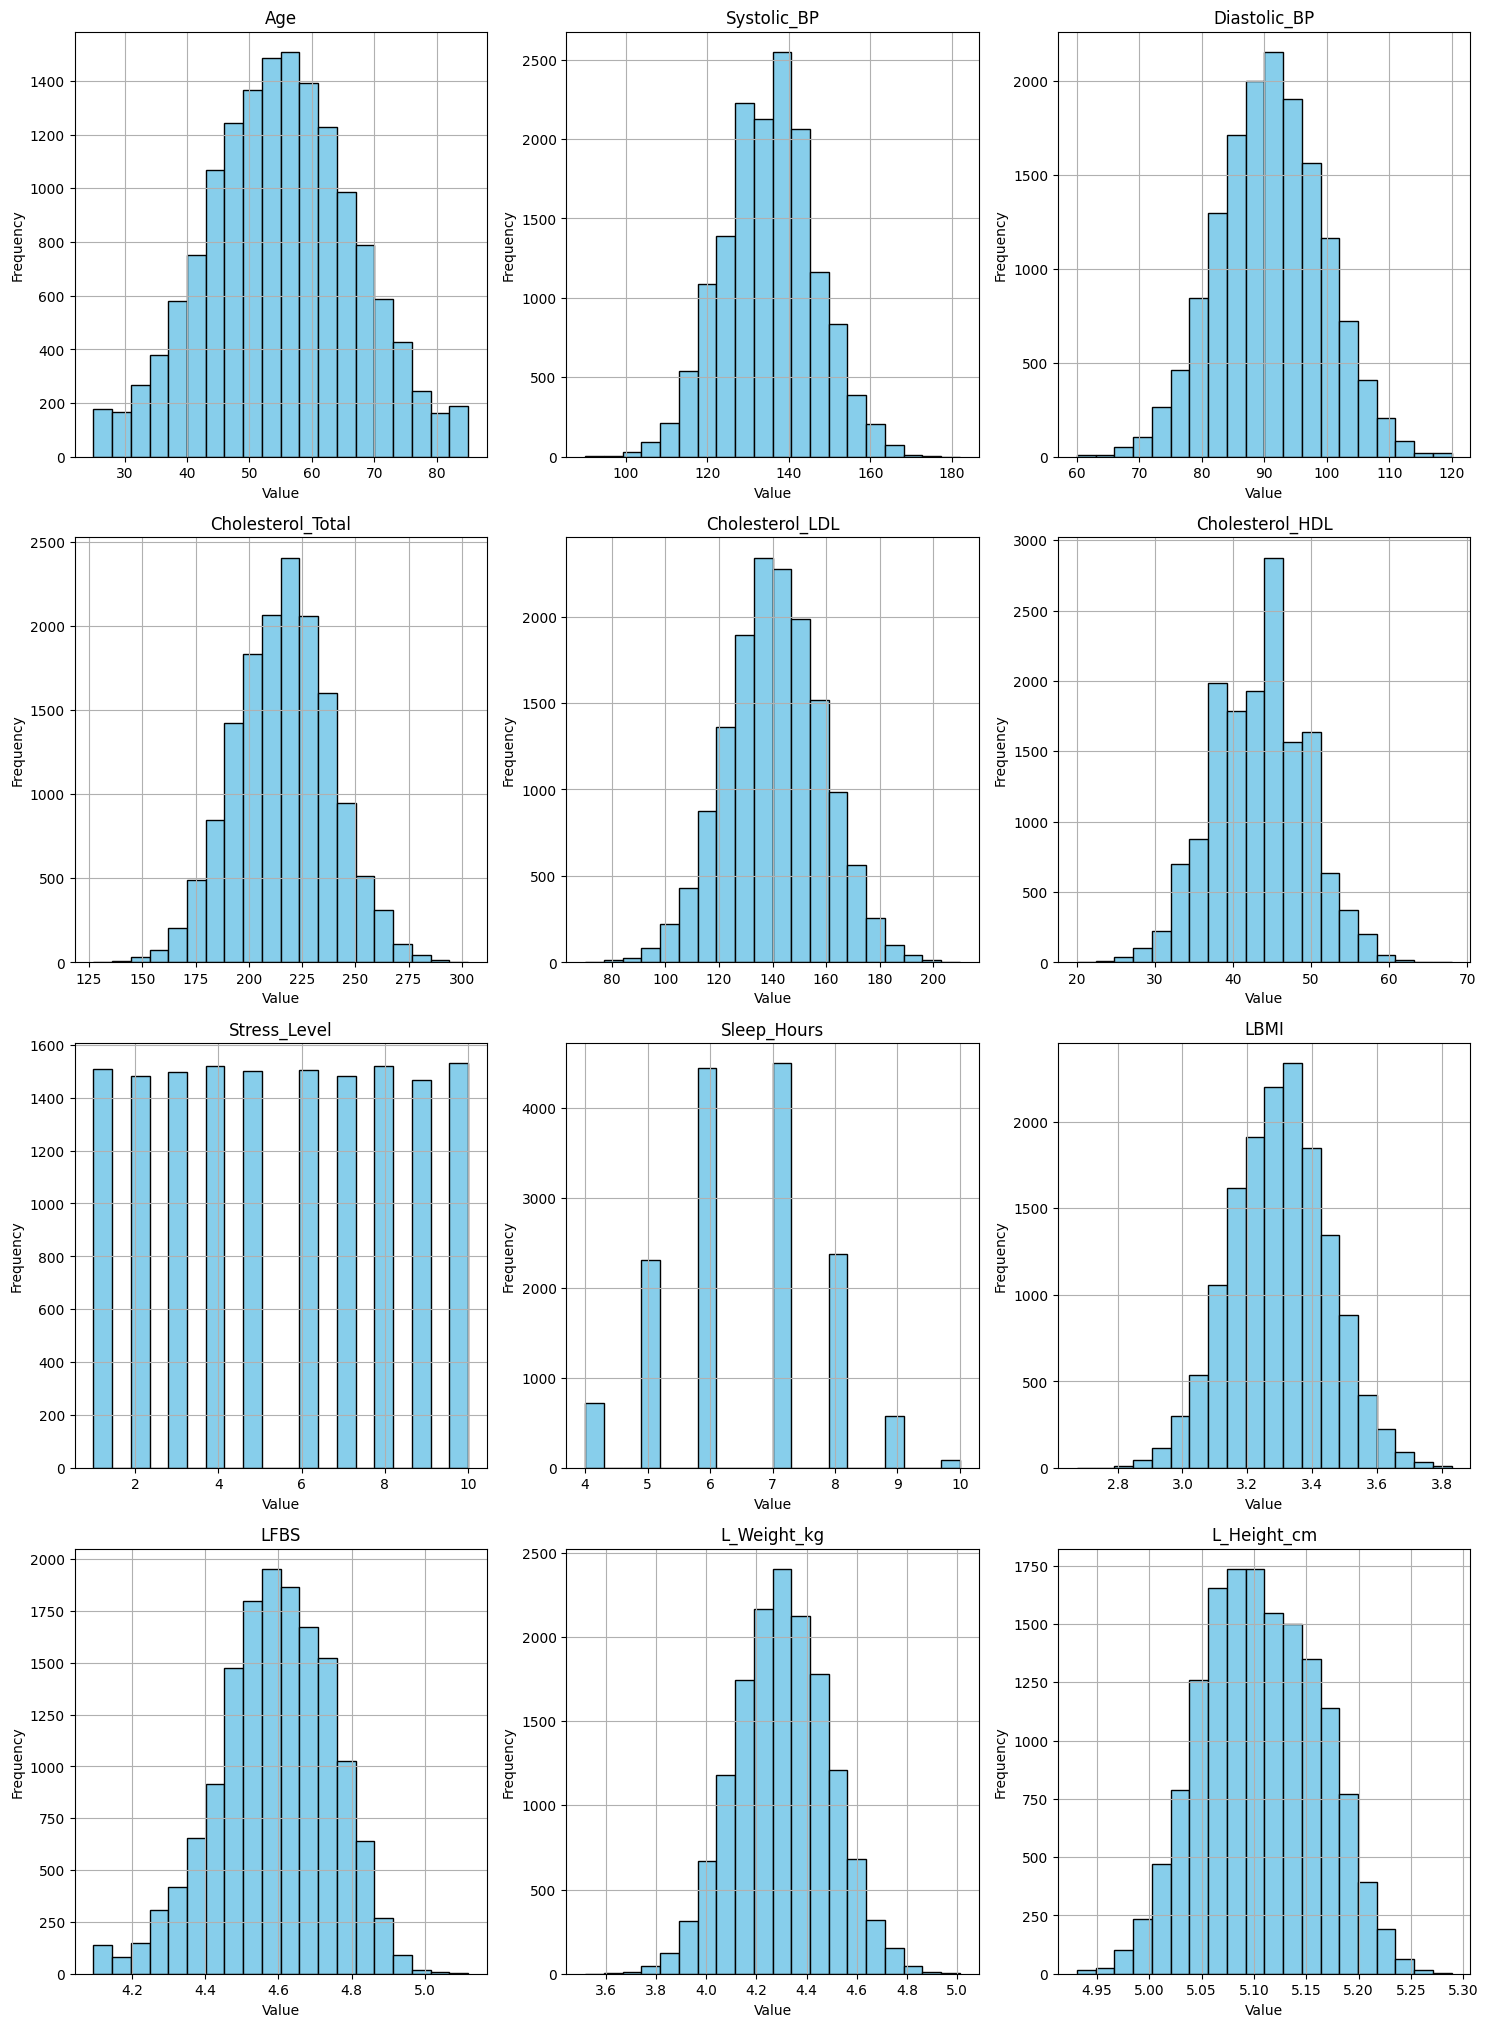

In [13]:
num_cols = 3  # Number of columns in the subplot grid
num_rows = 5  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, var in enumerate(quantitative_var):
    ax = axes[i]
    hsd[var].hist(ax=ax, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We have now better profiles for our quantitative variables.

## 3. Analyse multidimensionnelle

We are now interested by links between variables. If we find very clear linear link between 2 variables it will be interesting to check if one of variables can ben remove from a model.

['Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Stress_Level', 'Sleep_Hours', 'LBMI', 'LFBS', 'L_Weight_kg', 'L_Height_cm']


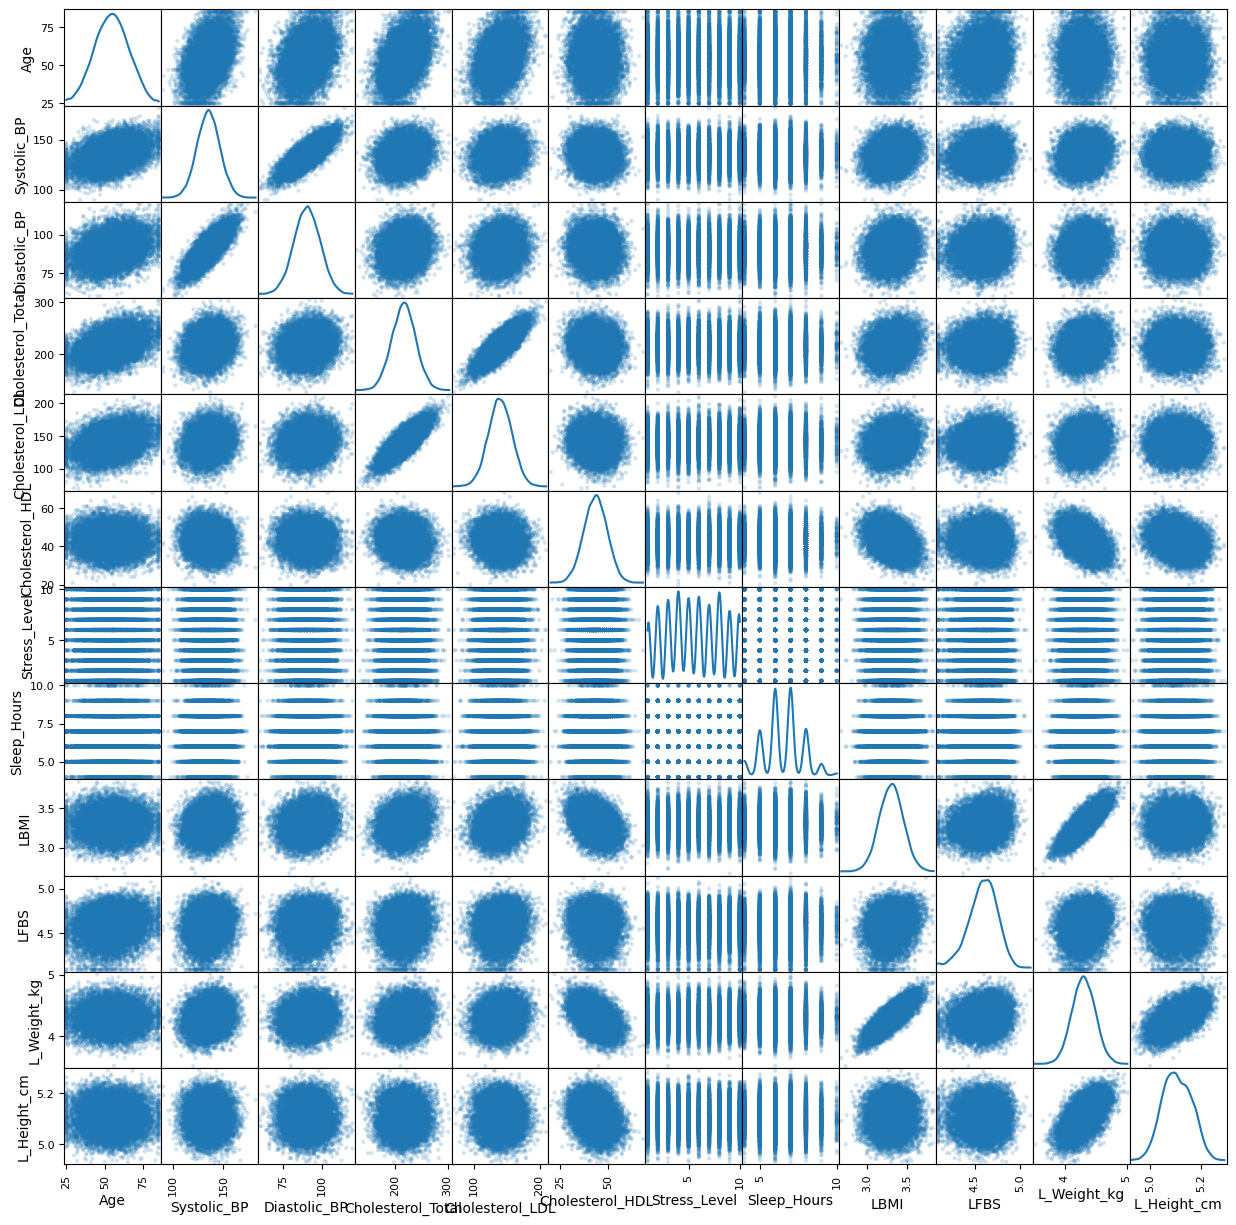

In [14]:
from pandas.plotting import scatter_matrix

print(quantitative_var)
scatter_matrix(hsd[quantitative_var], alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

Point clouds give us an idea of correlations between some variables so we can compute the Correlation Matrix to have a clear vision of those linear links.

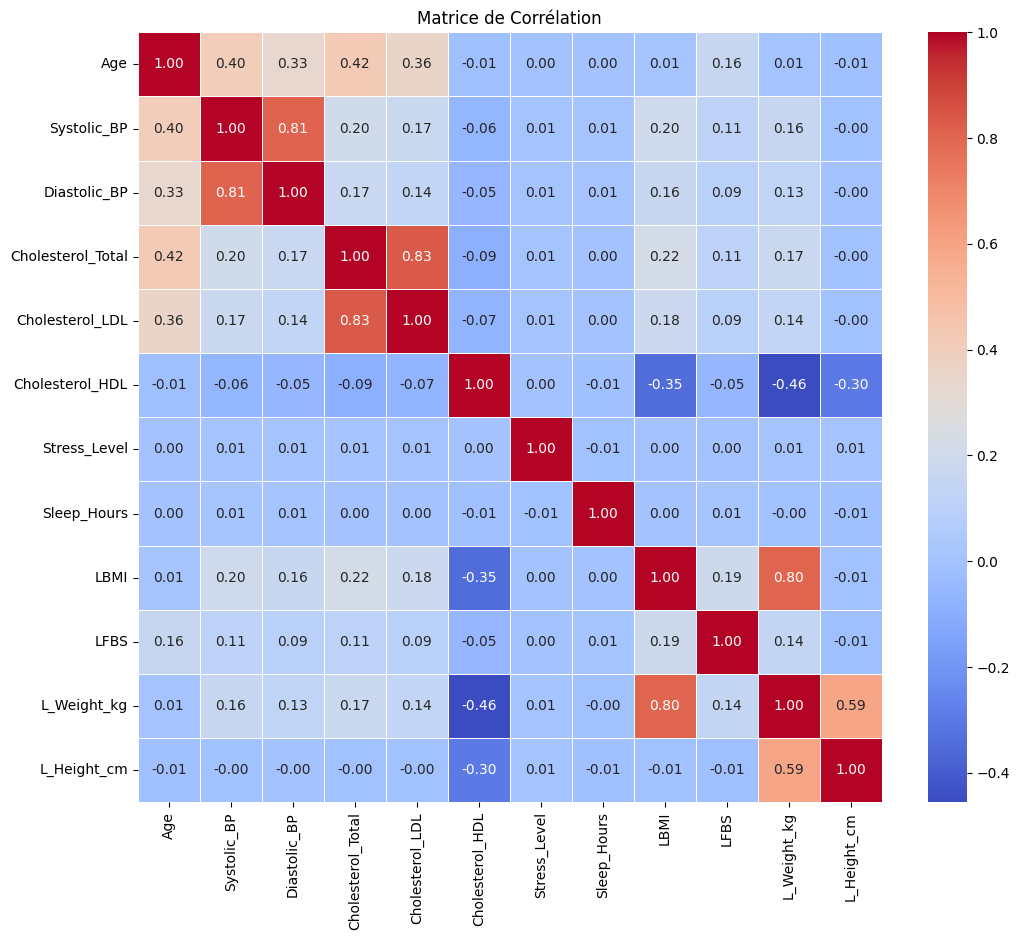

In [15]:
#matrice de correlation

corr_matrix = hsd[quantitative_var].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation")
plt.show()


We have some correlations to notice between the variables, for example:
- Cholesterol_HDL and L_Weight_kg (-0.46)
- Weight and Height at 0.59 (which seems normal)
- Cholesterol_Total and Cholesterol_LDL (0.83) so we can expect to see strong links between those variables, specially when we will try to estimate Cholesterol_HDL
- Systolic_BP and Diastolic_BP with 0.81, also we can expect a relation between those variables

We can keep those links in mind for reducing model afterwards. First, we will use ACP to try reduce the data and analyse how individuals are explained among each dimension.

### 1. ACP

ACP can only be used with quantitatives variables and we have a good proportion.

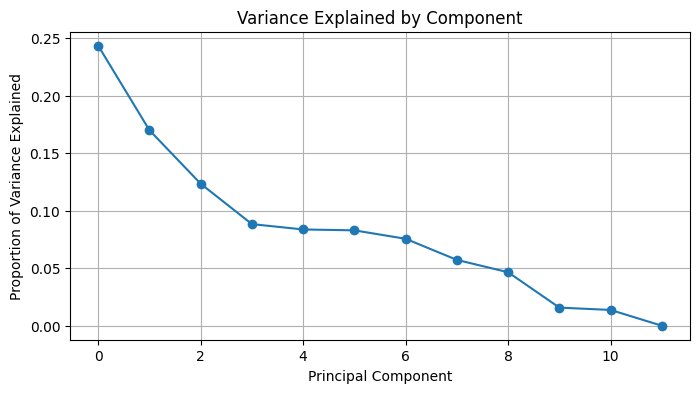

In [16]:
# Variable reduction
X=scale(hsd[quantitative_var])
pca = PCA()
## Estimation, calculation of principal components
C = pca.fit(X).transform(X)
# Decrease of explained variance
plt.figure(figsize=(8, 4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Variance Explained by Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid()

plt.show()

There is no clear number of components to explain well the data. We can see in a box plot for each components.

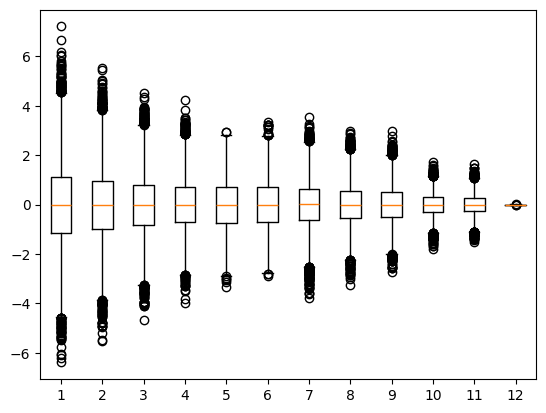

In [17]:
plt.boxplot(C[:,0:20])
plt.show()

We take the 3 first components to try to display the data in smaller dimension.

In [ ]:
#!! long time running cellule !!

from matplotlib.patches import Patch


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# dimension 1 and 2
for i, j, nom in zip(C[:,0], C[:,1], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[0].plot(i, j, "o", color=color)
axes[0].axis((-8, 8, -8, 8))
axes[0].set_title("PCA: Dimension 1 vs Dimension 2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# dimension 1 and 3
for i, j, nom in zip(C[:,0], C[:,2], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[1].plot(i, j, "o", color=color)
axes[1].axis((-8, 8, -8, 8))
axes[1].set_title("PCA: Dimension 1 vs Dimension 3")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")

# dimension 2 and 3
for i, j, nom in zip(C[:,1], C[:,2], hsd["Heart_Disease_Risk"]):
    color = "red" if nom else "blue"
    axes[2].plot(i, j, "o", color=color)
axes[2].axis((-8, 8, -8, 8))
axes[2].set_title("PCA: Dimension 2 vs Dimension 3")
axes[2].set_xlabel("PC2")
axes[2].set_ylabel("PC3")

# Add global legend
legend_elements = [Patch(facecolor='red', label='Heart Disease Risk'),
                   Patch(facecolor='blue', label='No Risk')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)

plt.tight_layout()
plt.show()






In [ ]:
#!! very long time running cellule !!
#dimension 1, 2 and 3
if False:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for i, j, k, nom in zip(C[:,0], C[:,1], C[:,2], hsd["Heart_Disease_Risk"]):
        color = "red" if nom  else "blue"
        ax.scatter(i, j, k, color=color)
    ax.set_xlabel('Composante 1')
    ax.set_ylabel('Composante 2')
    ax.set_zlabel('Composante 3')
    plt.title("Projection des données sur les 3 premières composantes principales")
    plt.show()

We have no clear separation between HDR individuals and no-HDR ones, for any components. However we can see that the HDR points are more concentrate in a place of the graph. The plot of components 1 and 3 give us the "best separation" so we can estimate that dimension 2 is less relevant for the separation. We now have a look to the variables and see how they participate for each components.

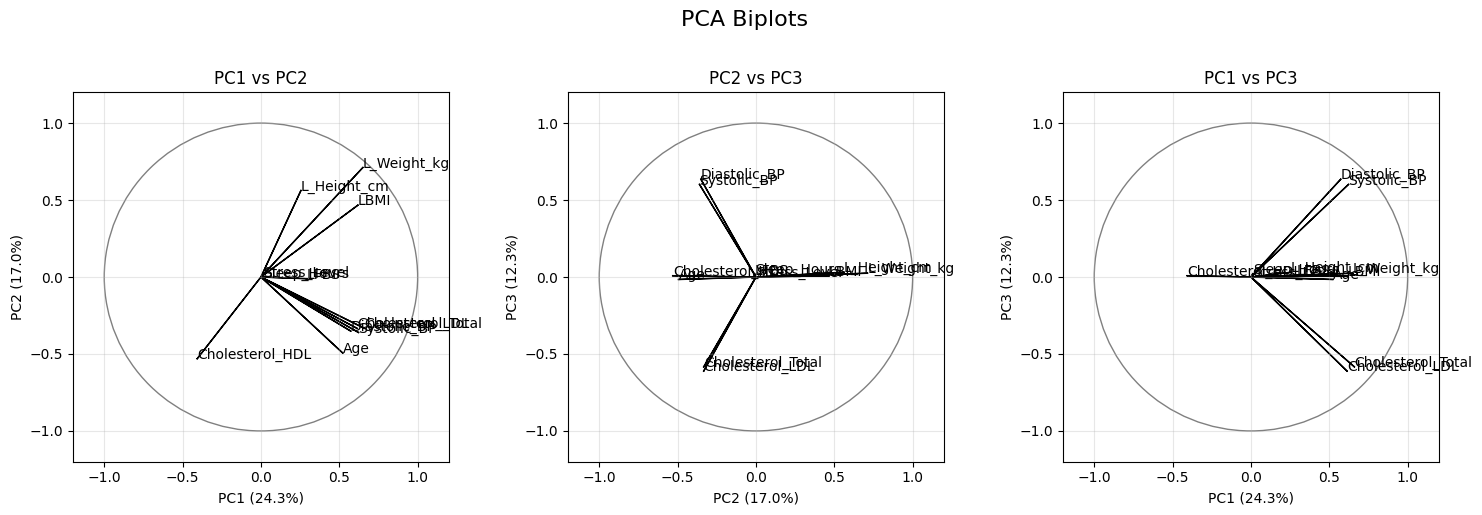

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PC1 vs PC2
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])
ax = axes[0]
for i, j, nom in zip(coord1, coord2, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC1 vs PC2")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.grid(True, alpha=0.3)
c1 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c1)

# PC2 vs PC3
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])
coord3 = pca.components_[2] * np.sqrt(pca.explained_variance_[2])
ax = axes[1]
for i, j, nom in zip(coord2, coord3, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC2 vs PC3")
ax.set_xlabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.grid(True, alpha=0.3)
c2 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c2)

# PC1 vs PC3
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord3 = pca.components_[2] * np.sqrt(pca.explained_variance_[2])
ax = axes[2]
for i, j, nom in zip(coord1, coord3, hsd[quantitative_var].columns):
    ax.text(i, j, nom)
    ax.arrow(0, 0, i, j, color='black')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"PC1 vs PC3")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.grid(True, alpha=0.3)
c3 = plt.Circle((0, 0), radius=1, color='gray', fill=False)
ax.add_patch(c3)

fig.suptitle("PCA Biplots", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


We can see that many variables are correlated together within these 3 dimensions. Futhermore, Dimension 2 and 3 have the same shape but inverted.

On dimensions 1 and 2, we have :
- L_weight_kg / LBMI / Height_cm wich are well represented and correlated together

On dimensions 2 and 3, variables are too badly represented.

On dimension 1 and 3, we have a good representation and a correlation with :
- Dialostic_BP and Systolic_BP
- Cholesterol_Total and Cholesterol_LDL

We find the same links than in the correlation matrix.

### Clustering with K-means

In [ ]:
from sklearn.cluster  import  KMeans
from  sklearn.metrics  import confusion_matrix
clust=KMeans(n_clusters=4)
clust.fit(X)
classe=clust.labels_
print(classe)
classe.shape

[3 0 0 ... 2 1 3]


(15000,)

[1 0 0 ... 3 2 1]


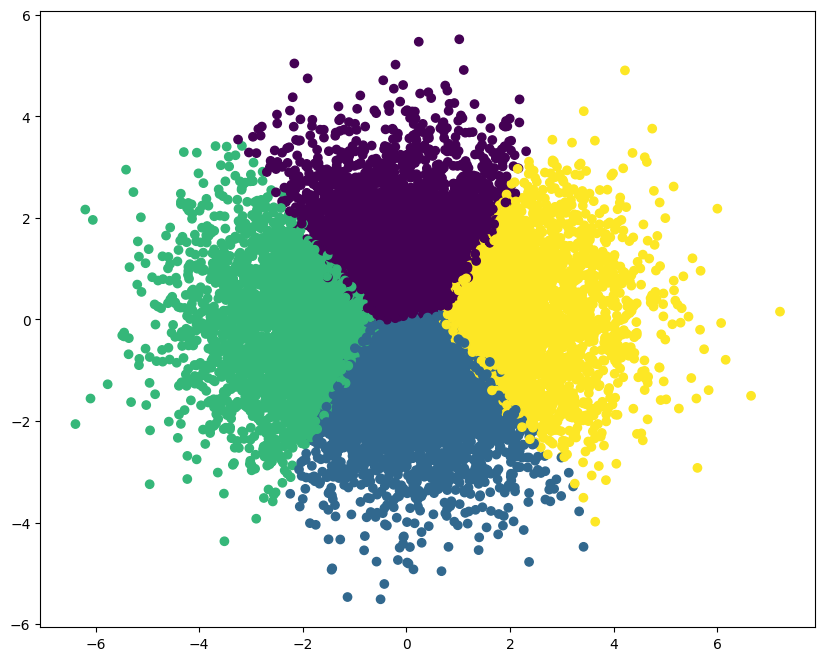

[2 1 0 ... 0 1 2]


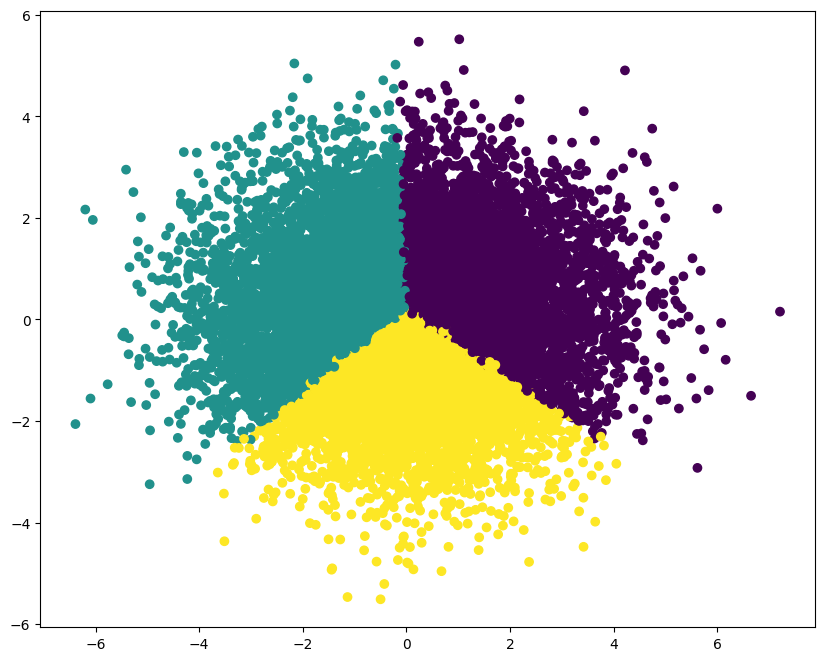

[1 1 0 ... 0 1 0]


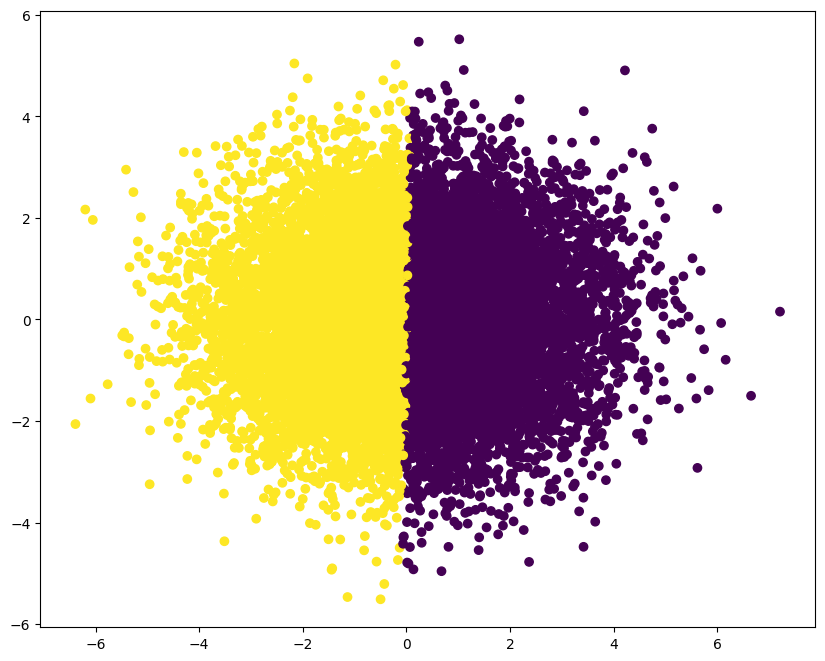

In [ ]:
from sklearn.cluster  import  KMeans
from  sklearn.metrics  import confusion_matrix
clust_4=KMeans(n_clusters=4)
clust_4.fit(X)
classe_4=clust_4.labels_
print(classe_4)
classe_4.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_4) 
plt.show()

clust_3=KMeans(n_clusters=3)
clust_3.fit(X)
classe_3=clust_3.labels_
print(classe_3)
classe_3.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_3) 
plt.show()

clust_2=KMeans(n_clusters=2)
clust_2.fit(X)
classe_2=clust_2.labels_
print(classe_2)
classe_2.shape

plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe_2) 
plt.show()

Since k-means algorithms is not a supervised learning method, we cannot directly compare the clusters obtained with the actual labels of "Heart_Disease_Risk". However, we can analyze the distribution of the actual labels within each cluster to see if there is any meaningful separation.

In [ ]:
hsd["Cluster_4"] = classe_4
hsd["Cluster_3"] = classe_3
hsd["Cluster_2"] = classe_2

# Analyze distribution of actual labels within each cluster for 4 clusters
print("Distribution of Heart Disease Risk within each Cluster (4 Clusters):")
for cluster in range(4):
    cluster_data = hsd[hsd["Cluster_4"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")

# Analyze distribution of actual labels within each cluster for 3 clusters
print("\nDistribution of Heart Disease Risk within each Cluster (3 Clusters):")
for cluster in range(3):
    cluster_data = hsd[hsd["Cluster_3"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")

# Analyze distribution of actual labels within each cluster for 2 clusters
print("\nDistribution of Heart Disease Risk within each Cluster (2 Clusters):")
for cluster in range(2):
    cluster_data = hsd[hsd["Cluster_2"] == cluster]
    risk_distribution = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    print(f"\nCluster {cluster}:")
    print(risk_distribution.round(1).astype(str) + "%")



Distribution of Heart Disease Risk within each Cluster (4 Clusters):

Cluster 0:
Heart_Disease_Risk
0    61.2%
1    38.8%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    51.8%
1    48.2%
Name: proportion, dtype: str

Cluster 2:
Heart_Disease_Risk
0    70.5%
1    29.5%
Name: proportion, dtype: str

Cluster 3:
Heart_Disease_Risk
1    58.9%
0    41.1%
Name: proportion, dtype: str

Distribution of Heart Disease Risk within each Cluster (3 Clusters):

Cluster 0:
Heart_Disease_Risk
1    52.8%
0    47.2%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    69.5%
1    30.5%
Name: proportion, dtype: str

Cluster 2:
Heart_Disease_Risk
0    51.9%
1    48.1%
Name: proportion, dtype: str

Distribution of Heart Disease Risk within each Cluster (2 Clusters):

Cluster 0:
Heart_Disease_Risk
1    53.2%
0    46.8%
Name: proportion, dtype: str

Cluster 1:
Heart_Disease_Risk
0    65.9%
1    34.1%
Name: proportion, dtype: str


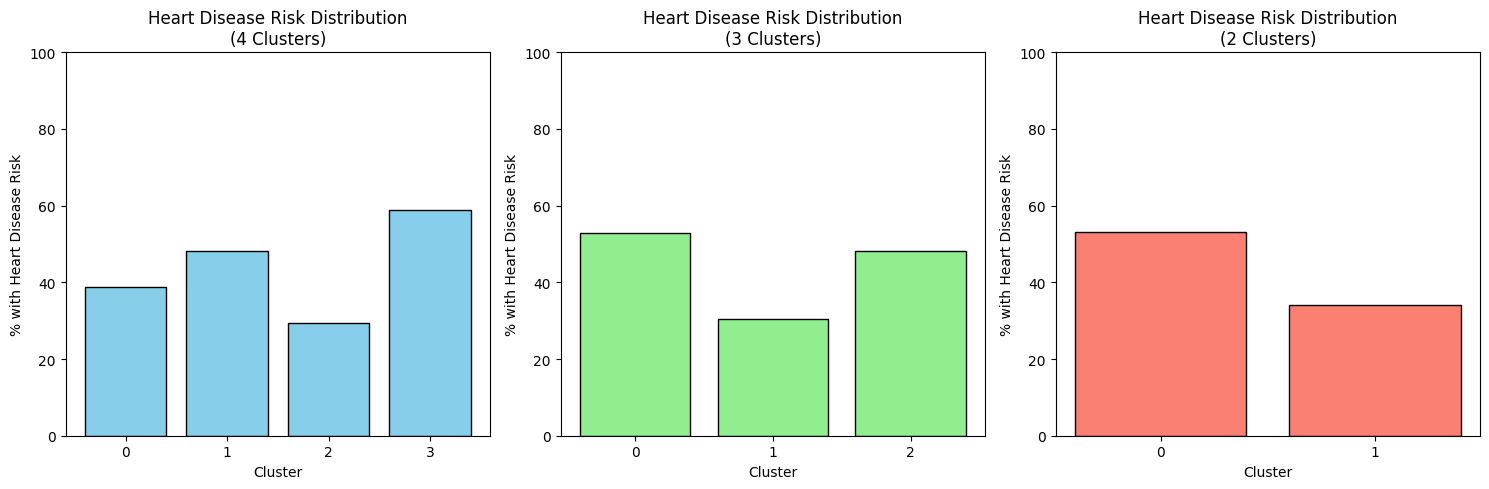

In [ ]:
# Add cluster assignments if not already present
if "Cluster_4" not in hsd.columns:
    hsd["Cluster_4"] = classe_4
    hsd["Cluster_3"] = classe_3
    hsd["Cluster_2"] = classe_2

# Visualization of cluster distributions for Heart Disease Risk
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 4 Clusters
cluster_4_dist = []
for cluster in range(4):
    cluster_data = hsd[hsd["Cluster_4"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_4_dist.append(risk_pct.get(1, 0))

axes[0].bar(range(4), cluster_4_dist, color='skyblue', edgecolor='black')
axes[0].set_title("Heart Disease Risk Distribution\n(4 Clusters)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("% with Heart Disease Risk")
axes[0].set_xticks(range(4))
axes[0].set_ylim(0, 100)

# 3 Clusters
cluster_3_dist = []
for cluster in range(3):
    cluster_data = hsd[hsd["Cluster_3"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_3_dist.append(risk_pct.get(1, 0))

axes[1].bar(range(3), cluster_3_dist, color='lightgreen', edgecolor='black')
axes[1].set_title("Heart Disease Risk Distribution\n(3 Clusters)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("% with Heart Disease Risk")
axes[1].set_xticks(range(3))
axes[1].set_ylim(0, 100)

# 2 Clusters
cluster_2_dist = []
for cluster in range(2):
    cluster_data = hsd[hsd["Cluster_2"] == cluster]
    risk_pct = cluster_data["Heart_Disease_Risk"].value_counts(normalize=True) * 100
    cluster_2_dist.append(risk_pct.get(1, 0))

axes[2].bar(range(2), cluster_2_dist, color='salmon', edgecolor='black')
axes[2].set_title("Heart Disease Risk Distribution\n(2 Clusters)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("% with Heart Disease Risk")
axes[2].set_xticks(range(2))
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


As we could expect with the distribution of points, we cannot compute a good separation in the data between the two classes with basic clustering (Heart Disease Risk and No Heart Disease Risk) using PCA and K-means. The clusters formed do not show a clear distinction between the two groups, indicating that the features used may not be sufficient to differentiate between patients with and without heart disease risk.

This suggests that either additional features are needed or that a different modeling approach may be necessary to effectively classify the patients based on their heart disease risk. That's why we will try different models seen in the Machine Learning course to see if we can get better results.

# Modelization

Our goal is to compare the performance of several modelization methods :
- Linear model (with/without : variable selection and penalization)
- SVR/SVM
- optimal tree
- random forest
- boosting
- neural networks

For each model we will identify the hyperparameters and adjust them with cross validation methods. 

#### Data set

In [ ]:
hsd_clean = hsd.drop("Patient_ID",axis=1)

In [ ]:
## Divide the dataset : train and test samples 

### HEART DISEASE RISK
hsd_clean_copy= hsd_clean.copy()
y_heart= hsd_clean_copy["Heart_Disease_Risk"]
X_heart= hsd_clean_copy.drop("Heart_Disease_Risk",axis=1)
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

### CHOLESTEROL LEVEL
hsd_clean_copy= hsd_clean.copy()
y_chol= hsd_clean_copy["Cholesterol_LDL"]
X_chol= hsd_clean_copy.drop(["Cholesterol_LDL", "Heart_Disease_Risk"], axis=1)
X_chol_train, X_chol_test, y_chol_train, y_chol_test = train_test_split(X_chol, y_chol, test_size=0.2, random_state=42)

This step is necessary to be able to make a realistic evaluation of our model and to make sure we do not have an overfitted model.

### 1. Linear model



a) Model selection

b) Variable selection (AIC, BIC, pvalue)

c) Penalization (Lasso, Ridge, ElasticNet, None)

##### Model

Since the `Heart_Disease_Risk` is a qualitative variable (binary), we will use a logistic regression model. This variable measures the risk of having a heart disease, where over 0.5 we consider the patient to be at high risk and under 0.5 at low risk.

Since the `Cholesterol_LDL` is a quantitative variable, we will use a linear regression model. This variable measures the Low-Density Lipoprotein / "Bad" cholesterol in mg/dL.

##### Metrics

To quantify the performance of our models, we are going to be using the following metrics :
* Logistic Regression : accuracy, specificity, sensitivity, AUC, number of variables (complexity or our model)
* Linear Regression : MSE, RMSE, R2, MAE, number of variables (complexity or our model)

In [ ]:
### HEART DISEASE RISK - logistic regression

# Fit the model + predict the classes

logi = LogisticRegression(max_iter=5000).fit(X_heart_train, y_heart_train)
y_pred_logi_class = logi.predict(X_heart_test)

print("---HEART DISEASE RISK---")
print(f"Logistic Regression Score : {logi.score(X_heart_test, y_heart_test)}")
print("Logistic Regression Accuracy:", accuracy_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression AUC:", roc_auc_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression Sensitivity:", confusion_matrix(y_heart_test, y_pred_logi_class)[1][1] / (confusion_matrix(y_heart_test, y_pred_logi_class)[1][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[1][1]))
print("Logistic Regression Specificity:", confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] / (confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[0][1]))
print("Logistic Regression Number of Variables:", len(X_heart.columns))

### CHOLESTEROL LEVEL - linear regression

# Fit the model + predict the values
linreg = LinearRegression().fit(X_chol_train, y_chol_train)
y_pred_linreg = linreg.predict(X_chol_test)

print("---CHOLESTEROL LEVEL---")
print(f"Linear Regression R^2 Score : {linreg.score(X_chol_test, y_chol_test)}")
print("Linear Regression MSE:", mean_squared_error(y_chol_test, y_pred_linreg))
print("Linear Regression RMSE:", sqrt(mean_squared_error(y_chol_test, y_pred_linreg)))
print("Linear Regression MAE:", mean_absolute_error(y_chol_test, y_pred_linreg))
print("Linear Regression Number of Variables:", len(X_chol.columns))

---HEART DISEASE RISK---
Logistic Regression Score : 0.7363333333333333
Logistic Regression Accuracy: 0.7363333333333333
Logistic Regression AUC: 0.7251397148028081
Logistic Regression Sensitivity: 0.6385911179173047
Logistic Regression Specificity: 0.8116883116883117
Logistic Regression Number of Variables: 24
---CHOLESTEROL LEVEL---
Linear Regression R^2 Score : 0.7039163307279834
Linear Regression MSE: 92.76969520439272
Linear Regression RMSE: 9.631702611916166
Linear Regression MAE: 7.608392872950209
Linear Regression Number of Variables: 23


RISK OF HEART DISEASE : With logisitc regression, we seem to get an appropriate model overall, with an AUC of about 72%. This shows a good ability to distinguish our data points between the two classes and therefore predict if there is a risk of heart desease based on several patient features. We want to control the risk of not diagnosting a patient that has a risk of heart disease. With a sensitivity of 0.63, we know that 37% of patients with heart disease risk are not diagnosed, which is a pretty high amount of missed predictions. On the contrary, with a specificity of 0.82, we predict the absence of risk to 82% of the healthy patients.

CHOLESTEROL LEVEL : Our linear regression model has a mean squared error of arounf 95%, which is an indicator of a high ability to predict closely enough the cholesterol level. However, we have a R2 of around 0.7 which shows that there is a bit of overfitting which might compromise the truthfulness of our high MSE value.

To make the accuracy analysis more robust, we can also use k-fold cross-validation. Instead of evaluating the model on a single train-test split, cross-validation repeatedly divides the data into different training and validation subsets and averages the results. This gives a more reliable estimate of model performance and reduces the risk that the conclusion depends too strongly on one particular split of the dataset.

##### Balancing classes

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000,class_weight='balanced'))])
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print("BALANCED : Mean CV AUC:", scores.mean())

pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000))])
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print("UNBALANCED : Mean CV AUC:", scores.mean())

BALANCED : Mean CV AUC: 0.8079034528714135
UNBALANCED : Mean CV AUC: 0.8078735159850756


Adding ``class_weight="balanced"`` did not improve the cross-validated AUC. The unweighted logistic regression achieved a slightly higher mean CV AUC, although the difference is negligible. This suggests that class imbalance is not a major issue for this model, or that reweighting does not bring additional predictive benefit in terms of discrimination.

#### b. Variable Selection

In this section we are going to use variable selection to get a more simple and interpretable model, even if we are aware that it could also be more unstable and overfit.

Hence we are going to determine a subset of predictors by adding and removing variables based on several citeria:
- AIC
- BIC
- p-values
- Lasso


##### i) AIC

In [ ]:
# AIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_aic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_aic = float("inf")
        # for every variable that has been excluded we find the one with the lowest AIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_aic < model_given(y, sm.add_constant(X[included])).fit(disp=0).aic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_aic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).aic
            # we remove the selected variable if the aic is lower when we remove it
            if new_aic < model.aic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included



##### ii) BIC

In [ ]:
# BIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_bic_FB(X, y, model_given):
    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_bic = float("inf")
        # for every variable that has been excluded we find the one with the lowest BIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_bic:
                best_bic = model.bic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_bic < model_given(y, sm.add_constant(X[included])).fit(disp=0).bic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_bic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).bic
            # we remove the selected variable if the aic is lower when we remove it
            if new_bic < model.bic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included


##### iii) p-value


In [ ]:
# P-value Algorithm (Forward-Backward) - returns the selected variables

def stepwise_pval_FB(X, y, model_given, entry_p=0.05, stay_p=0.05):
    included = []
    while True:
        changed = False

        ### FORWARD step
        excluded = list(set(X.columns) - set(included))
        best_pval = 1.0
        for col in excluded:
            model = model_given(y, sm.add_constant(X[included + [col]])).fit(disp=0)
            pval = model.pvalues[col]
            # we look for the varible with the lowest p-value
            if pval < best_pval:
                best_pval = pval
                best_feature = col
        # we check if adding the best selected variable gives us a p-value lower than the entry threshold
        if best_pval < entry_p:
            included.append(best_feature)
            changed = True

        ### BACKWARD step
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst_pval = pvals.max()
            # we remove the variable with the highest p-value if it is higher than the stay threshold
            if worst_pval > stay_p:
                worst_feature = pvals.idxmax()
                included.remove(worst_feature)
                changed = True

        # we stop the algorithm if no variable is added or removed
        if not changed:
            break
        
    return included




##### iv) Lasso

Lasso can be used to select a smaller subset of predictors, as it includes variable selection by putting a few coefficients down to zero, while ridge keeps all predictors but shrinks them never reaching zero.

In [ ]:
from sklearn import linear_model


def lasso_var_sel(X_train, y_train, alpha=0.01, graphs=False):

    # Reset index
    X = X_train.reset_index(drop=True)
    y = pd.Series(y_train).reset_index(drop=True)

    # Scale data (very important for LASSO)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit LASSO
    model_lasso = linear_model.Lasso(alpha=alpha)
    model_lasso.fit(X_scaled, y)

    # Get coefficients
    coef = pd.Series(model_lasso.coef_, index=X.columns)

    #print(f"Lasso keeps {sum(coef != 0)} variables and removes {sum(coef == 0)}")

    # Plot (optional)
    if graphs:
        imp_coef = coef[coef != 0].sort_values()
        plt.figure(figsize=(8, 10))
        imp_coef.plot(kind="barh")
        plt.title("LASSO Coefficients (non-zero)")
        plt.show()

    # Return selected variables
    return coef.index[coef != 0]


Variable selection algorithm comparison : AIC, BIC, p-value, Lasso

In [ ]:
def variable_selection(X_train, y_train, X_test, y_test, model, model_given, print_results=True):

    # Selected variables
    selected_variables_AIC = stepwise_aic_FB(X_train, y_train, model_given)
    selected_variables_BIC = stepwise_bic_FB(X_train, y_train, model_given)
    selected_variables_pval = stepwise_pval_FB(X_train, y_train, model_given)
    selected_variables_lasso = lasso_var_sel(X_train, y_train)

    # AIC Data set
    X_train_AIC = X_train[selected_variables_AIC]
    X_test_AIC = X_test[selected_variables_AIC] 
    X_train_BIC = X_train[selected_variables_BIC]
    X_test_BIC = X_test[selected_variables_BIC]
    X_train_pval = X_train[selected_variables_pval]
    X_test_pval = X_test[selected_variables_pval]
    X_train_lasso = X_train[selected_variables_lasso]
    X_test_lasso = X_test[selected_variables_lasso]


    # FIT

    pipeline_aic = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_bic = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_pval = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_aic.fit(X_train_AIC, y_train)
    pipeline_bic.fit(X_train_BIC, y_train)
    pipeline_pval.fit(X_train_pval, y_train)
    pipeline_lasso.fit(X_train_lasso, y_train)

    print(f"\n---{model}---")

    if model_given == sm.Logit:
        
        print(f"\nWITHOUT VARIABLE SELECTION : AUC (test set) : {roc_auc_score(y_test, model.fit(X_train, y_train).predict_proba(X_test)[:,1])}")

        # SCORE
        y_pred_proba = pipeline_aic.predict_proba(X_test_AIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AIC : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_bic.predict_proba(X_test_BIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"BIC : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_pval.predict_proba(X_test_pval)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"PVALUE : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_lasso.predict_proba(X_test_lasso)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"Lasso : {model} AUC (test set):", auc)

    else:

        print(f"\nWITHOUT VARIABLE SELECTION : MSE (test set) : {mean_squared_error(y_test, model.fit(X_train, y_train).predict(X_test))}")

        MSE_AIC = mean_squared_error(y_test, pipeline_aic.predict(X_test_AIC))
        print(f"AIC : {model} MSE (test set):", MSE_AIC)

        MSE_BIC = mean_squared_error(y_test, pipeline_bic.predict(X_test_BIC))
        print(f"BIC : {model} MSE (test set):", MSE_BIC)

        MSE_PVAL = mean_squared_error(y_test, pipeline_pval.predict(X_test_pval))
        print(f"PVALUE : {model} MSE (test set):", MSE_PVAL)

        MSE_LASSO = mean_squared_error(y_test, pipeline_lasso.predict(X_test_lasso))
        print(f"Lasso : {model} MSE (test set):", MSE_LASSO)

    print("\nSelected variables:")
    print("Selected variables AIC:", selected_variables_AIC)
    print("Selected variables BIC:", selected_variables_BIC)
    print("Selected variables P-value:", selected_variables_pval)
    print("Selected variables Lasso:", selected_variables_lasso)

    return selected_variables_AIC, selected_variables_BIC, selected_variables_pval, selected_variables_lasso

selected_variables_AIC_heart, selected_variables_BIC_heart, selected_variables_pval_heart, selected_variables_lasso_heart = variable_selection(X_heart_train, y_heart_train, X_heart_test, y_heart_test, LogisticRegression(max_iter=5000), sm.Logit)
selected_variables_AIC_chol, selected_variables_BIC_chol, selected_variables_pval_chol, selected_variables_lasso_chol = variable_selection(X_chol_train, y_chol_train, X_chol_test, y_chol_test, LinearRegression(), sm.OLS)



# sm:Logit and sm.OLS are the model_given for logistic regression and linear regression respectively from the statsmodels library

Lasso keeps 11 variables and removes 13

---LogisticRegression(max_iter=5000)---

WITHOUT VARIABLE SELECTION : AUC (test set) : 0.8057507715728514
AIC : LogisticRegression(max_iter=5000) AUC (test set): 0.8057995881328751
BIC : LogisticRegression(max_iter=5000) AUC (test set): 0.7989517095740122
PVALUE : LogisticRegression(max_iter=5000) AUC (test set): 0.8064807599472781
Lasso : LogisticRegression(max_iter=5000) AUC (test set): 0.8063957829724222

Selected variables:
Selected variables AIC: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'Fasting_Blood_Sugar', 'Stress_Level', 'Cholesterol_LDL', 'BMI', 'Age', 'Sleep_Hours', 'Cluster_3', 'Cholesterol_HDL', 'Weight_kg']
Selected variables BIC: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'LFBS', 'Stress_Level', 'Cholesterol_LDL', 'Sleep_Hours']
Selected variables P-value: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'Fasting_Blood_Sugar', '

##### Best variable selection method?
HEART DISEASE RISK :
We get very similar AUC scores for the four methods. BIC offers a lower AUC score (0.01 below) and the selected model only has 7 variables (AIC : 10 | p-value : 11 | Lasso : 16), which is very convenient for complexity matters. Therefore, BIC may be preferred for interpretability and model simplicity.

CHOLESTEROL LEVEL :
We get very similar MSE scores for the AIC, p-value and Lasso methods at around 92, while BIC has a higher value at around 94. Here the p-value method looks like the best compromise as it has the lowest MSE value and the second lowest number of selected variables after the BIC method. Therefore, the p-value method may be preferred for interpretability and model simplicity.

With or without variable selection ?

When we only consider a selected amount of our initial variables, we find ourselves with less complex and more accurate models. In our case, our results suggest that we should use the BIC variable selection for predicting Heart Disease Risk, with 7 variables left and an AUC of 0.80, as well as the p-value variable selection for predicting Cholesterol Level, with 11 variables and an MSE of 92.6.

#### c) Penalization

We are going to test how our model behaves when we add penalizations to it.

We will use Lasso (L1), Ridge (L2) and ElasticNet penalizations, two regularization techniques used to prevent overfitting by penalizing large coefficients. Lasso adds the absolute value of coefficients as a penalty, setting some to exactly zero for feature selection. Ridge adds the squared magnitude, shrinking coefficients toward zero but not removing variables. ElasticNet is a combination of Lasso and Ridge.


In [ ]:
# No Penalty 
logi_none = LogisticRegression(max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_none = LinearRegression().fit(X_chol_train, y_chol_train)
# Lasso (L1 only)
logi_l1 = LogisticRegression(l1_ratio=1.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l1 = Lasso(alpha=1.0).fit(X_chol_train, y_chol_train)
# Ridge (L2 only)
logi_l2 = LogisticRegression(l1_ratio=0.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l2 = Ridge(alpha=1.0).fit(X_chol_train, y_chol_train)
# ElasticNet (balanced L1 + L2)
logi_elastic = LogisticRegression(l1_ratio=0.5, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_elastic = ElasticNet(alpha=1.0).fit(X_chol_train, y_chol_train)

#--> we add the saga solver as lbfgs does not support elasticnet and lasso penalties
#--> we leave C=1 as default but it can be tuned to find the best value for each penalty

print("---HEART DISEASE---")
print(f"Logistic Regression Score (No Penalty) : {logi_none.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Lasso) : {logi_l1.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Ridge) : {logi_l2.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (ElasticNet) : {logi_elastic.score(X_heart_test, y_heart_test)}")
print("\n---CHOLESTEROL LEVEL---")
print(f"Linear Regression MSE Score (No Penalty) : {mean_squared_error(y_chol_test, linreg_none.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Lasso) : {mean_squared_error(y_chol_test, linreg_l1.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Ridge) : {mean_squared_error(y_chol_test, linreg_l2.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (ElasticNet) : {mean_squared_error(y_chol_test, linreg_elastic.predict(X_chol_test))}")



---HEART DISEASE---
Logistic Regression Score (No Penalty) : 0.7346666666666667
Logistic Regression Score (Lasso) : 0.7343333333333333
Logistic Regression Score (Ridge) : 0.7346666666666667
Logistic Regression Score (ElasticNet) : 0.7346666666666667

---CHOLESTEROL LEVEL---
Linear Regression MSE Score (No Penalty) : 92.76969520439272
Linear Regression MSE Score (Lasso) : 95.7234168453849
Linear Regression MSE Score (Ridge) : 92.74040807140976
Linear Regression MSE Score (ElasticNet) : 95.67350035833063


We get nearly equivalent scores, with Ridge, ElasticNet and no penalty being the most performant penalizations with C=1 set by default. However, we want to check if when choosing the optimal C for each method, we get the same results. Therefore, we are going to test our model on several values of C, the inverse of the regularization strength. 

Regularization penalizes large coefficients to avoid overfitting.
* If C is small, the model is more constrained, coefficients stay smaller, and the model is simpler.
* If C is large, the penalty is weaker, so the model can fit the training data more closely.

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

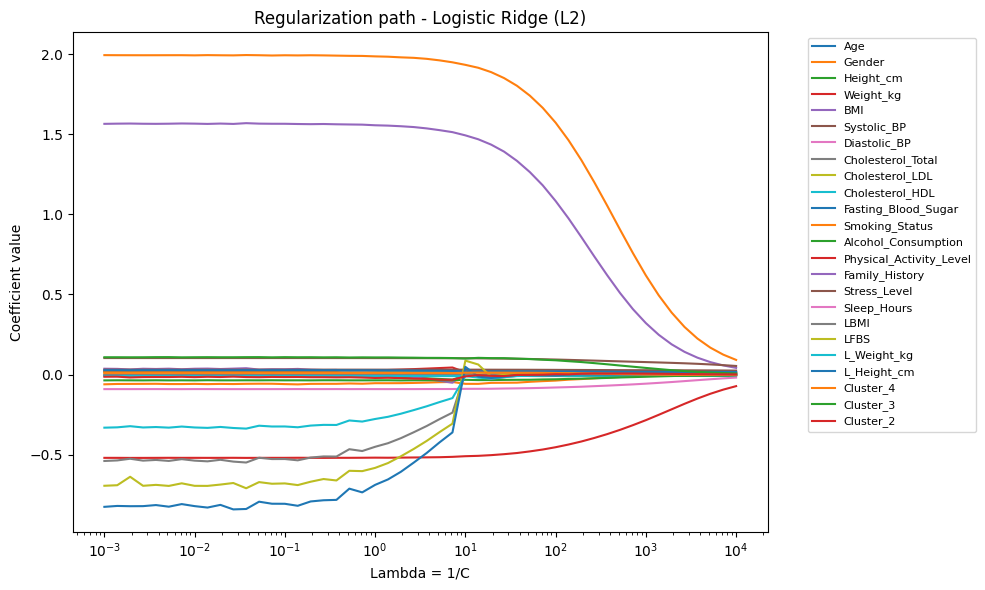

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat

In [ ]:
C_values = np.logspace(-4, 3, 50)   # from strong to weak regularization
lambda_values = 1 / C_values        # equivalent inverse regularization scale

# RIDGE logistic path (L2)

coef_ridge = []
feature_names = X_heart.columns

for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_ridge.append(model.coef_[0])

coef_ridge = np.array(coef_ridge)

plt.figure(figsize=(10, 6))
for i in range(coef_ridge.shape[1]):
    plt.plot(lambda_values, coef_ridge[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Ridge (L2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# LASSO logistic path (L1)

coef_lasso = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_lasso.append(model.coef_[0])

coef_lasso = np.array(coef_lasso)

plt.figure(figsize=(10, 6))
for i in range(coef_lasso.shape[1]):
    plt.plot(lambda_values, coef_lasso[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Lasso (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ELASTICNET logistic path (balanced L1 + L2)

coef_elasticnet = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_elasticnet.append(model.coef_[0])

coef_elasticnet = np.array(coef_elasticnet)

plt.figure(figsize=(10, 6))
for i in range(coef_elasticnet.shape[1]):
    plt.plot(lambda_values, coef_elasticnet[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic ElasticNet (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

We now want to determine the best combination of penalization method, C parameter value and solver used. For this matter we are going to put in a place a GridSearch.


In [ ]:
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

pipeline_reglin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])


param_grid_log = [
    {
        "model__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag"],
        "model__penalty": ["l2"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    },
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2", "elasticnet"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100],
        "model__l1_ratio": np.linspace(0, 1, 10)   # only used for elasticnet
    },
    {
        "model__solver": ["saga", "lbfgs", "newton-cg", "newton-cholesky"],
        "model__penalty": [None],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    }
]

param_grid_reg = [
    {
        "model": [Ridge()],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [Lasso(max_iter=5000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [ElasticNet(max_iter=5000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [LinearRegression()]
    }
]

grid_log = GridSearchCV(
    pipeline_log,
    param_grid=param_grid_log,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_reglin = GridSearchCV(
    pipeline_reglin,
    param_grid=param_grid_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_log.fit(X_heart_train, y_heart_train)
grid_reglin.fit(X_chol_train, y_chol_train)

print("Best parameters:", grid_log.best_params_)
print("Best CV AUC:", grid_log.best_score_)

print("Best parameters:", grid_reglin.best_params_)
print("Best CV MSE:", grid_reglin.best_score_)


KeyboardInterrupt: 

##### Binomial deviance

c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

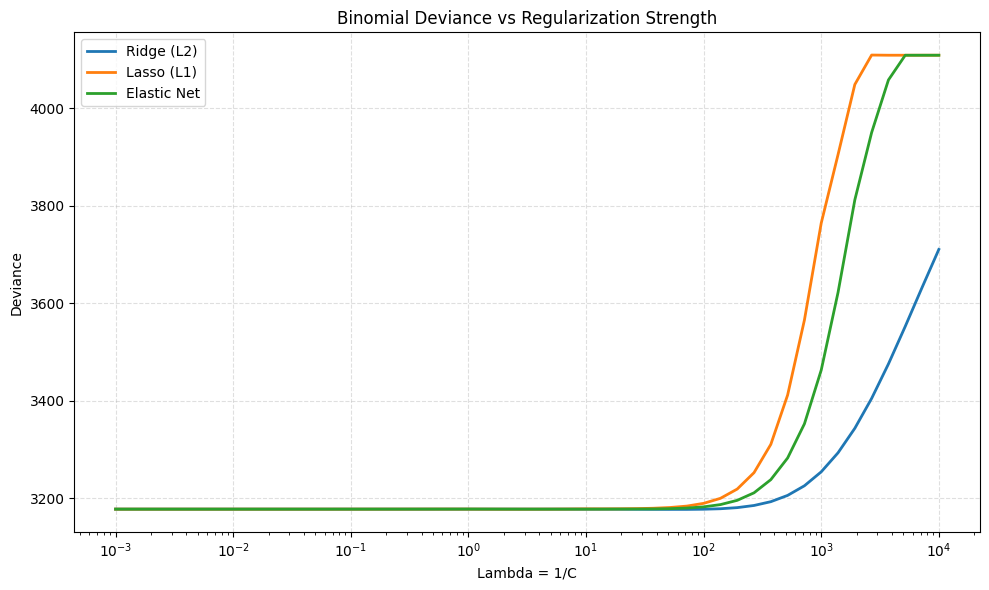

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

# Scale data
scaler = StandardScaler()
X_heart_train_scaled = scaler.fit_transform(X_heart_train)
X_heart_test_scaled = scaler.transform(X_heart_test)

# Regularization grid
C_values = np.logspace(-4, 3, 50)   # weak -> strong in sklearn sense
lambda_values = 1 / C_values        # more intuitive penalization scale

# Containers
deviance_ridge = []
deviance_lasso = []
deviance_elasticnet = []

# ---------- RIDGE ----------
for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    # Binomial deviance = 2 * log-loss * n
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_ridge.append(dev)

# ---------- LASSO ----------
for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_lasso.append(dev)

# ---------- ELASTIC NET ----------
for C in C_values:
    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,   # 50% L1, 50% L2
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_elasticnet.append(dev)

# ---------- PLOT ----------
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, deviance_ridge, label="Ridge (L2)", linewidth=2)
plt.plot(lambda_values, deviance_lasso, label="Lasso (L1)", linewidth=2)
plt.plot(lambda_values, deviance_elasticnet, label="Elastic Net", linewidth=2)

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Deviance")
plt.title("Binomial Deviance vs Regularization Strength")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Conclusion 

Let us find the best models for predicting the risk of heart disease and cholesterol level : with or without variable selection and penalization.

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000, C=0.01))])

pipeline_variable_selection = Pipeline([
    ('scaler', StandardScaler()),
    ('logi', LogisticRegression(max_iter=5000))
])

pipeline_penalty = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

pipeline_penalty_variable_selection = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

X_heart_train_BIC = X_heart_train[stepwise_bic_FB(X_heart_train, y_heart_train, sm.Logit)]
scores_simplistic = cross_val_score(pipeline, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty = cross_val_score(pipeline_penalty, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")

print("Mean CV AUC (Simplistic):", scores_simplistic.mean())
print("Mean CV AUC (Variable Selection):", scores_variable_selection.mean())
print("Mean CV AUC (Penalty):", scores_penalty.mean())
print("Mean CV AUC (Penalty + Variable Selection):", scores_penalty_variable_selection.mean())

c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Mean CV AUC (Simplistic): 0.807000651808225
Mean CV AUC (Variable Selection): 0.8004415613389291
Mean CV AUC (Penalty): 0.807151448451535
Mean CV AUC (Penalty + Variable Selection): 0.8004313971612314


c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


The best linear model for the heart disease risk prediction is therefore the logistic regression without penalization nor variable selection, which gives us a 0.80760 AUC score. It is important to mention that we almost get the same performance for the other cases, with less than a 0.01 difference, so the best strategy is to take the simplest model possible.

c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\alexb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty

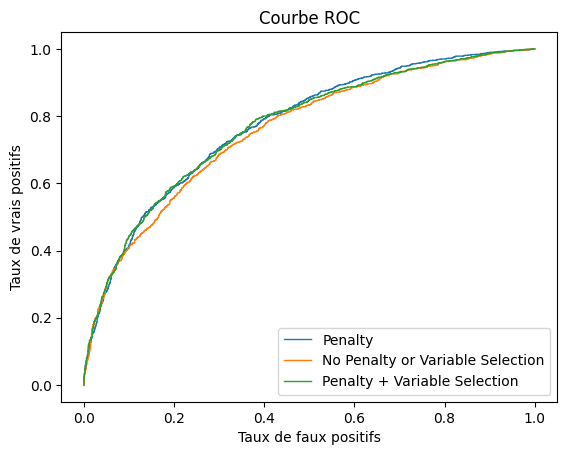

In [ ]:
from sklearn.metrics import roc_curve

param=[{"C":[1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_pen, tpr_pen, thresholds_pen = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(penalty=None), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty=None,
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_none, tpr_none, thresholds_none = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train[selected_variables_BIC_heart], y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train[selected_variables_BIC_heart], y_heart_train).predict_proba(X_heart_test[selected_variables_BIC_heart])
fpr_pen_var, tpr_pen_var, thresholds_pen_var = roc_curve(y_heart_test, probas_[:,1])




plt.plot(fpr_pen, tpr_pen, lw=1)
plt.plot(fpr_none, tpr_none, lw=1)
plt.plot(fpr_pen_var, tpr_pen_var, lw=1)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(['Penalty', 'No Penalty or Variable Selection', 'Penalty + Variable Selection'], loc='lower right')
plt.show()

From the graph we would say that the best strategy is taking the model with only the penalty, which is contradictory with what we just had found!

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])

pipeline_variable_selection = Pipeline([
    ('scaler', StandardScaler()),
    ('logi', LinearRegression())
])

pipeline_penalty = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

pipeline_penalty_variable_selection = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

X_chol_train_BIC = X_chol_train[stepwise_bic_FB(X_chol_train, y_chol_train, sm.OLS)]
scores_simplistic = cross_val_score(pipeline, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty = cross_val_score(pipeline_penalty, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")

print("Mean CV MSE (Simplistic):", -scores_simplistic.mean())
print("Mean CV MSE (Variable Selection):", -scores_variable_selection.mean())
print("Mean CV MSE (Penalty):", -scores_penalty.mean())
print("Mean CV MSE (Penalty + Variable Selection):", -scores_penalty_variable_selection.mean())

Mean CV MSE (Simplistic): 101.24980279220014
Mean CV MSE (Variable Selection): 101.06408165130382
Mean CV MSE (Penalty): 101.0840387487148
Mean CV MSE (Penalty + Variable Selection): 101.07394492921765


The best linear model for the cholesterol level prediction is therefore the linear regression without penalization nor variable selection, which gives us a 101.02 MSE score. It is important to mention that we almost get the same performance for the other cases, with less than a difference of 1, so the best strategy is to take the simplest model possible.

## 2. SVR/SVM

In this section, we are going to be using support vectors to make our predictions, SVM for `Heart_Disease_Risk` and SVR for `Cholestrol_LDL`.

For that matter, we will be tuning our parameters `C` and `gamma` through a cross-validation grid.

We will normalize our data before operating SVM, since this model is very sensitive to the scale of our data. Therefore we will standarize our variables to ensure that they all contribute in a comparable way to the distance calculus. This increases the stability of our model.

In [ ]:
scaler_heart = StandardScaler()
X_heart_train_scaled = scaler_heart.fit_transform(X_heart_train)
X_heart_test_scaled = scaler_heart.transform(X_heart_test)

scaler_chol = StandardScaler()
X_chol_train_scaled = scaler_chol.fit_transform(X_chol_train)
X_chol_test_scaled = scaler_chol.transform(X_chol_test)


In [ ]:

param_heart = {
    "C": [0.01, 0.05, 0.1],
    "gamma": [0.01, 0.03, 0.05],
    "kernel": ["rbf", "linear"]
}

param_chol = {
    "C": [0.01, 0.05, 0.1],
    "gamma": [0.01, 0.03, 0.05],
    "epsilon": [0.01, 0.03, 0.05],
    "kernel": ["rbf", "linear"]
}

svm_heart= GridSearchCV(SVC(probability=True),param_heart,cv=2,n_jobs=-1)
svmOpt_heart=svm_heart.fit(X_heart_train_scaled, y_heart_train)

svm_chol= GridSearchCV(SVR(),param_chol,cv=2,n_jobs=-1)
svmOpt_chol=svm_chol.fit(X_chol_train_scaled, y_chol_train)

# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt_heart.best_score_,svmOpt_heart.best_params_))
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt_chol.best_score_,svmOpt_chol.best_params_))

Meilleur score = 0.268167, Meilleur paramètre = {'C': 0.05, 'gamma': 0.01, 'kernel': 'rbf'}
Meilleur score = 0.302042, Meilleur paramètre = {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'linear'}


In [ ]:
# erreur de prévision sur le test
print(f"Test error (Heart): {1 - svmOpt_heart.score(X_heart_test_scaled, y_heart_test)}")
print(f"Test error (Cholesterol): {1 - svmOpt_chol.score(X_chol_test_scaled, y_chol_test)}")



Test error (Heart): 0.276
Test error (Cholesterol): 0.29433519070619774


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# =========================
# HEART DISEASE RISK - SVM
# =========================

y_heart_pred = svmOpt_heart.predict(X_heart_test_scaled)
y_heart_prob = svmOpt_heart.predict_proba(X_heart_test_scaled)[:, 1]

svm_score = svmOpt_heart.score(X_heart_test_scaled, y_heart_test)
svm_accuracy = accuracy_score(y_heart_test, y_heart_pred)
svm_auc = roc_auc_score(y_heart_test, y_heart_prob)

tn, fp, fn, tp = confusion_matrix(y_heart_test, y_heart_pred).ravel()

svm_sensitivity = tp / (tp + fn)
svm_specificity = tn / (tn + fp)
svm_n_variables = X_heart_train.shape[1]

print("---HEART DISEASE RISK---")
print(f"SVM Score: {svm_score}")
print(f"SVM Accuracy: {svm_accuracy}")
print(f"SVM AUC: {svm_auc}")
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")
print(f"SVM Number of Variables: {svm_n_variables}")


# =========================
# CHOLESTEROL LEVEL - SVR
# =========================

y_chol_pred = svmOpt_chol.predict(X_chol_test_scaled)

svr_r2 = r2_score(y_chol_test, y_chol_pred)
svr_mse = mean_squared_error(y_chol_test, y_chol_pred)
svr_rmse = np.sqrt(svr_mse)
svr_mae = mean_absolute_error(y_chol_test, y_chol_pred)
svr_n_variables = X_chol_train.shape[1]

print("---CHOLESTEROL LEVEL---")
print(f"SVR R^2 Score: {svr_r2}")
print(f"SVR MSE: {svr_mse}")
print(f"SVR RMSE: {svr_rmse}")
print(f"SVR MAE: {svr_mae}")
print(f"SVR Number of Variables: {svr_n_variables}")

---HEART DISEASE RISK---
SVM Score: 0.724
SVM Accuracy: 0.724
SVM AUC: 0.797006731261221
SVM Sensitivity: 0.610260336906585
SVM Specificity: 0.8116883116883117
SVM Number of Variables: 24
---CHOLESTEROL LEVEL---
SVR R^2 Score: 0.7056648092938023
SVR MSE: 92.2218574123887
SVR RMSE: 9.603221199805235
SVR MAE: 7.598940729527349
SVR Number of Variables: 23



##### Heart Disease Risk (SVM)

- **Score (0.724)**: The model correctly predicts about 72% of the observations.  
- **Accuracy (0.724)**: The overall proportion of correct predictions is good for this type of problem.  
- **AUC (0.797)**: The model has a good ability to distinguish between patients with and without heart disease.  
- **Sensitivity (0.610)**: The model detects around 61% of patients who actually have heart disease, which indicates some missed positive cases.  
- **Specificity (0.812)**: The model correctly identifies about 81% of healthy individuals, showing strong performance on the negative class.  
- **Number of variables (24)**: The model uses 24 features, which provides a relatively rich representation of the data.  

##### Cholesterol Level (SVR)

- **R² Score (0.706)**: The model explains about 70% of the variance in cholesterol levels, which indicates a solid fit.  
- **MSE (92.22)**: The average squared prediction error is moderate, reflecting the overall deviation from true values.  
- **RMSE (9.60)**: The typical prediction error is around 9.6 units, giving an interpretable scale of the error.  
- **MAE (7.60)**: The average absolute error is about 7.6 units, confirming that predictions are reasonably close to the true values.  
- **Number of variables (23)**: The model relies on 23 features to make predictions.  

##### Conclusion

- The SVM classifier shows good global performance but could be improved in sensitivity to better detect positive cases.  
- The SVR model provides accurate and stable predictions, with no strong indication of extreme errors.  

### Improvements

In [ ]:
# Adjusting the decision threshold for SVM
y_prob = svmOpt_heart.predict_proba(X_heart_test_scaled)[:, 1]
y_pred_threshold = (y_prob > 0.4).astype(int)  # lower threshold

# Balanced SVM with class weights
svmOpt_heart_new = SVC(class_weight='balanced', probability=True).fit(X_heart_train_scaled, y_heart_train)
y_heart_pred_new = svmOpt_heart_new.predict(X_heart_test_scaled)
y_heart_prob_new = svmOpt_heart_new.predict_proba(X_heart_test_scaled)[:, 1]

# SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=10)
X_heart_train_selected = selector.fit_transform(X_heart_train_scaled, y_heart_train)
X_heart_test_selected = selector.transform(X_heart_test_scaled)
svmOpt_heart_selected = SVC(class_weight='balanced', probability=True).fit(X_heart_train_selected, y_heart_train)
y_heart_pred_selected = svmOpt_heart_selected.predict(X_heart_test_selected)


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import pandas as pd

def classification_metrics(y_true, y_pred, y_prob, n_variables):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Number of Variables": n_variables
    }


# =========================
# BEFORE - Original SVM
# =========================
y_heart_pred = svmOpt_heart.predict(X_heart_test_scaled)
y_heart_prob = svmOpt_heart.predict_proba(X_heart_test_scaled)[:, 1]

metrics_before = classification_metrics(
    y_heart_test,
    y_heart_pred,
    y_heart_prob,
    X_heart_train.shape[1]
)


# =========================
# AFTER 1 - Threshold = 0.4
# =========================
y_pred_threshold = (y_heart_prob > 0.4).astype(int)

metrics_threshold = classification_metrics(
    y_heart_test,
    y_pred_threshold,
    y_heart_prob,
    X_heart_train.shape[1]
)


# =========================
# AFTER 2 - Balanced SVM
# =========================
svmOpt_heart_new = SVC(class_weight="balanced", probability=True).fit(
    X_heart_train_scaled,
    y_heart_train
)

y_heart_pred_new = svmOpt_heart_new.predict(X_heart_test_scaled)
y_heart_prob_new = svmOpt_heart_new.predict_proba(X_heart_test_scaled)[:, 1]

metrics_balanced = classification_metrics(
    y_heart_test,
    y_heart_pred_new,
    y_heart_prob_new,
    X_heart_train.shape[1]
)


# =========================
# AFTER 3 - SelectKBest
# =========================
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_heart_train_selected = selector.fit_transform(X_heart_train_scaled, y_heart_train)
X_heart_test_selected = selector.transform(X_heart_test_scaled)

svmOpt_heart_selected = SVC(class_weight="balanced", probability=True).fit(
    X_heart_train_selected,
    y_heart_train
)

y_heart_pred_selected = svmOpt_heart_selected.predict(X_heart_test_selected)
y_heart_prob_selected = svmOpt_heart_selected.predict_proba(X_heart_test_selected)[:, 1]

metrics_selected = classification_metrics(
    y_heart_test,
    y_heart_pred_selected,
    y_heart_prob_selected,
    10
)


# =========================
# COMPARISON TABLE
# =========================
comparison = pd.DataFrame({
    "Before - Original SVM": metrics_before,
    "After - Threshold 0.4": metrics_threshold,
    "After - Balanced SVM": metrics_balanced,
    "After - SelectKBest": metrics_selected
}).T

comparison = comparison.round(3)

print(comparison)

                       Accuracy    AUC  Sensitivity  Specificity  \
Before - Original SVM     0.724  0.797        0.610        0.812   
After - Threshold 0.4     0.721  0.797        0.705        0.733   
After - Balanced SVM      0.723  0.788        0.696        0.744   
After - SelectKBest       0.724  0.775        0.698        0.745   

                       Number of Variables  
Before - Original SVM                 24.0  
After - Threshold 0.4                 24.0  
After - Balanced SVM                  24.0  
After - SelectKBest                   10.0  


In [ ]:

# prediction
y_heart_pred = svmOpt_heart.predict(X_heart_test_scaled)

# full confusion table
table_heart = pd.crosstab(
    # we have to convert the predictions and the true labels to categorical variables with the same categories to avoid errors in the crosstab function
    # otherwise we had one of the two categories missing in the predictions and it was not able to create the table
    pd.Categorical(y_heart_pred, categories=[0, 1]),
    pd.Categorical(y_heart_test, categories=[0, 1]),
    rownames=["Predicted"],
    colnames=["Actual"]
)

print("Confusion Matrix SVM: Heart Disease Risk")
print(table_heart)


Confusion Matrix SVM: Heart Disease Risk
Actual        0    1
Predicted           
0          1375  509
1           319  797

Confusion Matrix SVM: Cholesterol Level
Empty DataFrame
Columns: []
Index: []


C:\Users\lenovoyoga914\AppData\Local\Temp\ipykernel_15940\3847069293.py:16: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(y_chol_pred, categories=[0, 1]),
C:\Users\lenovoyoga914\AppData\Local\Temp\ipykernel_15940\3847069293.py:17: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(y_chol_test, categories=[0, 1]),


## 3. Arbre Optimal

## 4. Forêt aléatoire

## 5. Boosting

## 6. Neural Networks